# The Overnight GRF Pilot — a guided tour

**What this notebook is.** On the night of 2026-07-02 → 03 we ran a pre-registered
"kill test" for a research direction: *auditing the correctness of steered diffusion
samplers on problems where the right answer is known exactly.* **Part I** walks
through what we built, why, and what came out — assuming familiarity with Bayesian
inference and Wiener filtering, but **not** with diffusion samplers. **Part II**
covers the follow-up night (2026-07-03 → 04): four confirmatory arms, publicly
pre-registered, including an audit of the community's own validation tools.
**Part III** covers the program's honest pivot and its first new instrument: a
runtime error meter ("steering certificate") for guided samplers, and the
pre-registered kill test it survived. Every figure is regenerated live from the
result files in `../results/`.

**The one-sentence summary of the outcome:** the popular approximate ways of steering
a diffusion model toward data or a reward are *measurably, substantially* biased at
completely realistic settings — the bias grows with steering strength and with
dimension, it interacts with model misspecification in treacherous ways, and the one
method that is mathematically correct is correct in practice too. The pre-registered
kill criterion for the research program was decisively **not** triggered → **GO**.

---

## 1. The question, in plain terms

Generative diffusion models have become the workhorse *prior* in many inference
pipelines — including mass mapping, where a score-based model trained on simulations
plays the role that the lognormal or Gaussian prior used to play. But a prior alone
is useless; you want the **posterior**: the prior *conditioned on data*, or more
generally the prior *tilted* toward some reward.

The field has invented many ways to do this steering **at sampling time, without
retraining the model**. Almost all of them are approximations, and the approximations
are usually justified by "it looks fine" (nice images, plausible maps). Nobody can
easily check them on real problems, because on real problems *the true posterior is
unknown*.

Our question: **how wrong are these steering methods, when you can actually check?**
And is the wrongness big enough, at realistic settings, to justify building a whole
research program (audits + runtime certificates) around it?

This matters twice over for us:
1. **Cosmology**: if you do mass mapping / field-level inference with a diffusion
   prior and approximate guidance, your posterior widths and peak statistics inherit
   whatever bias the sampler has — silently.
2. **The bridge**: the same question ("does this sampling-time steering actually
   produce the distribution it claims?") is exactly what test-time search does to
   LLMs — the particle-reasoners project measured the discrete version of this
   phenomenon on math-solving LLMs. The pilot asks whether that phenomenology
   transfers to continuous, high-dimensional space.


---

## TL;DR — the whole night in plain language

*(No equations, no jargon; everything here is unpacked properly in the sections below.)*

**The motivation.** Modern AI image generators ("diffusion models") work by learning
to turn pure noise into realistic pictures. Scientists now use the same machinery for
inference: train such a model on simulated maps of the universe, and it becomes a
sophisticated prior — a statement of what plausible maps look like. To actually
answer questions, though, you must *steer* the generator: "give me plausible maps,
but only ones consistent with my telescope's data." Several popular steering recipes
exist, and nearly all of them are mathematical shortcuts. The worry: the shortcuts
might systematically distort the answers — and on real problems nobody can tell,
because nobody knows the exact right answer to compare against.

**The idea.** So we built a rigged arena: a simplified universe (a Gaussian random
field — think "cosmic texture with known statistics") where the exactly correct
answer to the steering problem IS known, in closed form, thanks to sixty-year-old
Wiener filter theory. Then we made the popular steering recipes compete on it,
overnight, on three GPUs — and measured precisely how far each one lands from the
truth. Before running anything, we wrote down our predictions and the "this whole
idea is dead if..." criterion, and froze them (pre-registration — the same discipline
clinical trials use, to keep ourselves honest).

**The contestants, as characters:**
- *The workhorse (DPS)* — the most popular recipe. Takes a clever shortcut: when
  weighing the data, it pretends its current best guess of the clean map is certain.
- *The tournament (reward-resampling)* — runs many candidate maps in parallel and
  repeatedly culls the ones that fit the data worst, cloning the ones that fit best.
- *The bookkeeper (proper twisted SMC)* — the mathematically correct method, which
  carefully tracks and corrects for every approximation it makes. Expensive-looking,
  rarely used in practice.
- *The lazy one (best-of-N)* — generate lots of maps ignoring the data, keep the
  ones that happen to fit. Fine in principle, hopeless in practice.
- Plus a *referee* (samples from the exact answer, defining the best possible score
  at a given budget) and a *control* (isolates numerical sloppiness from genuine
  method error).

**What we found.**
1. *The workhorse is confidently wrong everywhere.* Its shortcut makes it trust the
   data too much, so it produces answer-distributions that are too narrow and pushed
   too far — overconfidence, in the precise statistical sense (its "68% error bars"
   contain the truth far less than 68% of the time). The distortion grows the harder
   you steer, never disappears even for very gentle steering, and gets *worse*, not
   better, on bigger maps. We double-checked the measured distortion against pen-and-
   paper theory: agreement to about one percent.
2. *The tournament over-sharpens, and the damage compounds with every round* — the
   more selection rounds you run, the more overconfident the result. (The same law
   was measured before in AI language-model "test-time search"; it transfers.)
3. *The bookkeeper is exactly right, everywhere we looked* — and it's the only
   method that also reports an honest self-check number (an evidence estimate we
   could verify against the exact value). That self-check is the seed of a bigger
   idea: runtime "certificates" that could flag broken sampling in real analyses,
   where no ground truth exists.
4. *The nastiest finding:* if the learned prior is slightly wrong (in cosmology:
   trained on simulations with the wrong astrophysics), the errors can *cancel* the
   workhorse's overconfidence and make a doubly-broken pipeline look calibrated on
   simple diagnostics. Two wrongs faking a right — exactly the failure mode you'd
   never catch without an exact test bed.
5. *A side quest on language models:* the same night, a companion experiment measured
   how "test-time search" (generating many solution attempts and letting a reward
   model steer them) destroys a model's ability to know when it's right — and how
   reserving a slice of untouched attempts ("insurance") buys that ability back
   cheaply. A second experiment initially returned an absurd result (the model's
   confidence *anti*-predicted correctness) which a morning autopsy traced to a
   measurement bug — the model's long reasoning was being cut off mid-thought and
   miscounted — a neat live demonstration of why this whole reliability agenda
   matters: silent measurement failures look exactly like discoveries.

**The verdict.** The pre-registered kill criterion ("if no method is meaningfully
distorted at realistic settings, drop this research direction") was decisively NOT
met — the distortions are large, structured, and measurable. Four of five frozen
predictions scored as hits, one (deliberately betting against the project) as a miss.
Decision: **GO** — this becomes the seed of a research program on auditing and
certifying steered generative samplers, with the night's code as its foundation.


## 2. The testbed: a problem where the answer is exactly known

The trick that makes the whole night possible: pick a problem where the "tilted
posterior" is a **Wiener posterior** — an object we can write down in closed form,
mode by mode.

**Prior.** A Gaussian random field on an $n\times n$ grid:
$$p(x) = \mathcal{N}(0, C), \qquad C \;\text{diagonal in Fourier space with power spectrum}\; P(k) \propto k^{\,n_s-4}\,e^{-(k/k_{\rm cut})^2}$$
with $n_s = 0.96$ — a steep red, cosmology-flavored spectrum, normalized to unit
pixel variance. (Realism is irrelevant here; *exactness* is everything.)

**Observation / reward.** A linear observation $y = A x_{\rm truth} + \text{noise}$,
where $A$ is a Gaussian smoothing (diagonal in Fourier space: multiply mode $k$ by
$a(k) = e^{-k^2/2k_s^2}$), and a quadratic reward
$$r(x) = -\frac{\lVert Ax - y\rVert^2}{2s^2}.$$

**The target.** Steering the prior by this reward at inverse strength $\beta$ means
sampling
$$\sigma(x) \;\propto\; p(x)\, e^{\,r(x)/\beta},$$
and because everything is Gaussian and diagonal in Fourier space, $\sigma$ **is** the
per-mode Wiener posterior with effective noise $b = \beta s^2$:
$$\Sigma^*_k = \Big(\frac{1}{P_k} + \frac{a_k^2}{b}\Big)^{-1}, \qquad
\mu^*_k = \Sigma^*_k\, \frac{a_k\, y_k}{b}.$$

Small $\beta$ → strong steering (data trusted a lot); large $\beta$ → gentle nudge.
Rather than quote raw $\beta$, we calibrate it so the posterior mean moves by
$\{0.5, 1, 2, 4\}$ prior standard deviations (RMS across modes) — "tilt strength in
sigmas" is the honest, transferable knob.

Because every quantity of interest — score, marginals, optimal twist, $W_2$, KL,
evidence $Z$ — has a per-mode closed form, **a null result cannot be blamed on
estimator noise, and any bias we measure can be cross-checked analytically.**


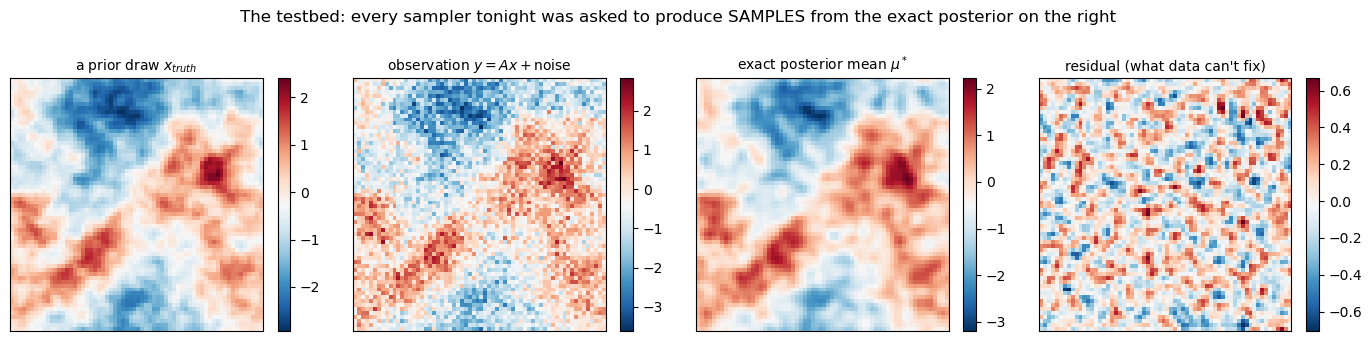

This is just Wiener filtering — the point is that the FULL posterior (mean AND covariance, mode by mode) is known exactly.


In [1]:
# Setup + a picture of the testbed: prior draw, observation, exact posterior mean
import json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve() if Path("../results").exists() else Path(
    "/home/tersenov/software/tilt-audit")
PR = Path("/home/tersenov/software/particle-reasoners")
rng = np.random.default_rng(7)

def load(*patterns, root=ROOT / "results"):
    rows = []
    for pat in patterns:
        for f in glob.glob(str(root / pat)):
            rows += [json.loads(l) for l in open(f) if l.strip()]
    return pd.DataFrame(rows)

# --- tiny self-contained re-implementation of the testbed (numpy only) ---
n = 64
k1 = np.fft.fftfreq(n, d=1/n)
KX, KY = np.meshgrid(k1, k1, indexing="ij")
K = np.hypot(KX, KY)
P = np.maximum(K, 1.0) ** (0.96 - 4.0) * np.exp(-(K / (0.7 * n / 2)) ** 2)
P /= P.mean()                          # unit pixel variance
a = np.exp(-0.5 * (K / (0.25 * n)) ** 2)   # smoothing operator
def draw_grf():
    white = np.fft.fft2(rng.normal(size=(n, n)))
    return np.fft.ifft2(white * np.sqrt(P)).real
x_truth = draw_grf()
s_obs = 0.5
y_map = np.fft.ifft2(np.fft.fft2(x_truth) * a).real + s_obs * rng.normal(size=(n, n))
# Wiener posterior mean for a mid-strength tilt (b chosen for illustration)
b = 0.05
Yk = np.fft.fft2(y_map)
Sig = 1.0 / (1.0 / P + a**2 / b)
mu_k = Sig * a * Yk / b
post_mean = np.fft.ifft2(mu_k).real

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, img, title in zip(
        axes, [x_truth, y_map, post_mean, x_truth - post_mean],
        ["a prior draw $x_{truth}$", "observation $y = Ax + $noise",
         "exact posterior mean $\\mu^*$", "residual (what data can't fix)"]):
    im = ax.imshow(img, cmap="RdBu_r"); ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("The testbed: every sampler tonight was asked to produce SAMPLES "
             "from the exact posterior on the right", y=1.05)
plt.tight_layout(); plt.show()
print("This is just Wiener filtering — the point is that the FULL posterior "
      "(mean AND covariance, mode by mode) is known exactly.")

## 3a. Background: what a diffusion model actually is

Forget neural networks for a moment. The problem diffusion models solve is ancient:
**you have samples from a complicated distribution $p(x)$ and want a machine that
generates more of them.** Direct density modeling is hard. The diffusion trick is to
convert this one hard problem into a *sequence of easy ones*:

1. Take your data and progressively drown it in Gaussian noise. After enough noise,
   the distribution is just $\mathcal{N}(0, I)$ — trivial to sample.
2. Learn to undo **one small noising step at a time**. Each undo step is a tiny,
   nearly-Gaussian inference problem — much easier than modeling $p$ wholesale.
3. To generate: start from pure noise and run the undo steps backwards.

The undoing turns out to require exactly one object at each noise level $t$: the
**score** of the noisy distribution,
$$s_t(x) \;=\; \nabla_x \log p_t(x),$$
the vector field that points "uphill in probability". Intuition: if I hand you a
noisy field and you know which direction makes it *more typical*, you can walk it
back toward the data manifold. Anderson's classic result (1982) makes this exact:
the noising process run in reverse is again a diffusion, with the score as its extra
drift term (equation below).

Why is the score *learnable*? Because of a beautiful identity (denoising score
matching): the score of the noisy marginal is equivalent to the conditional
expectation of the clean signal — so you can train a network by the utterly mundane
task of **predicting the noise you just added**. That's the entire training loop of
every diffusion model: add noise, predict it, repeat. No partition functions, no
adversarial games.

The cosmology connection you already own: a score model trained on N-body-derived
convergence maps is a *simulation prior* — it plays the exact role $\mathcal{N}(0,C)$
plays in Wiener filtering, but for the full non-Gaussian field. Tonight's testbed
deliberately uses the Gaussian case so that everything the samplers do can be checked
against Wiener-posterior closed forms.


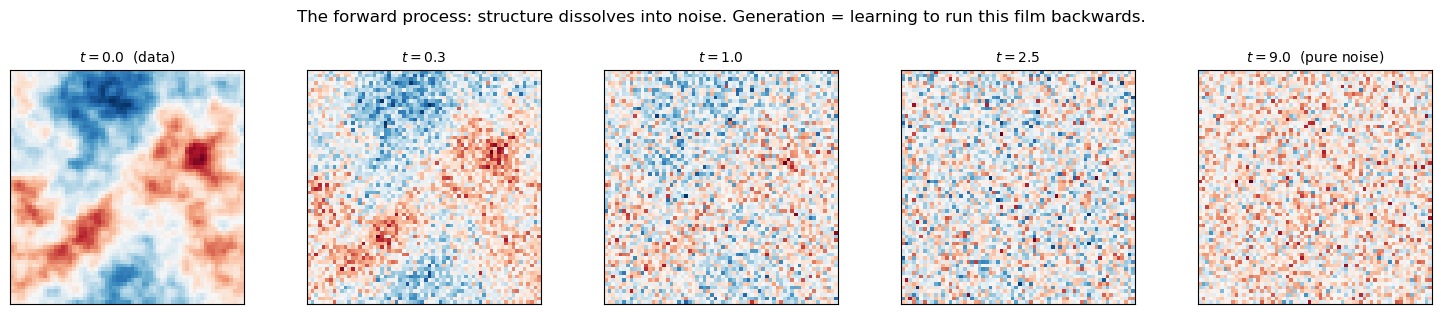

In [2]:
# Visual: the forward (noising) process on a real GRF — the "film strip"
ts_show = [0.0, 0.3, 1.0, 2.5, 9.0]
fig, axes = plt.subplots(1, len(ts_show), figsize=(15, 3))
for ax, t in zip(axes, ts_show):
    alpha_t, sig_t = np.exp(-t), np.sqrt(1 - np.exp(-2 * t))
    xt = alpha_t * x_truth + sig_t * rng.normal(size=(n, n))
    ax.imshow(xt, cmap="RdBu_r"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"$t = {t}$" + ("  (data)" if t == 0 else
                                 "  (pure noise)" if t == 9 else ""), fontsize=10)
plt.suptitle("The forward process: structure dissolves into noise. Generation = "
             "learning to run this film backwards.", y=1.03)
plt.tight_layout(); plt.show()

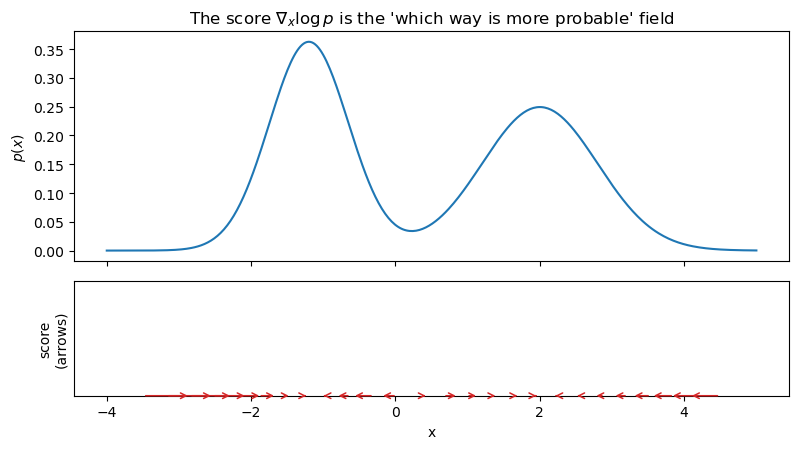

Following the arrows (plus the right amount of noise) IS sampling. That's the reverse diffusion.


In [3]:
# Visual: what "the score" means, in 1-D where you can see it
from scipy.stats import norm as gauss
xs = np.linspace(-4, 5, 400)
p_mix = 0.5 * gauss.pdf(xs, -1.2, 0.55) + 0.5 * gauss.pdf(xs, 2.0, 0.8)
logp = np.log(p_mix); score = np.gradient(logp, xs)
fig, axes = plt.subplots(2, 1, figsize=(8, 4.6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(xs, p_mix, "C0"); axes[0].set_ylabel("$p(x)$")
axes[0].set_title("The score $\\nabla_x \\log p$ is the 'which way is more probable' field")
for x0 in np.linspace(-3.5, 4.5, 26):
    s = np.interp(x0, xs, score)
    axes[1].annotate("", xy=(x0 + 0.11 * np.clip(s, -6, 6), 0), xytext=(x0, 0),
                     arrowprops=dict(arrowstyle="->", color="C3", lw=1.1))
axes[1].axhline(0, color="gray", lw=.5); axes[1].set_yticks([])
axes[1].set_xlabel("x"); axes[1].set_ylabel("score\n(arrows)")
plt.tight_layout(); plt.show()
print("Following the arrows (plus the right amount of noise) IS sampling. "
      "That's the reverse diffusion.")

## 3b. The reverse process, Tweedie, and our closed-form playground

Now the machinery, concretely. **Forward (noising) process** — an
Ornstein–Uhlenbeck SDE; in our convention, at time $t$:
$$x_t = e^{-t} x_0 + \sqrt{1 - e^{-2t}}\;\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I),$$
so at $t=0$ you have data and by $t_f = 9$ you have essentially pure white noise.

**The reverse (denoising) process.** Run time backwards. The magic identity: to
reverse the noising you only need the **score** $\nabla_x \log p_t(x)$ — "which
direction is uphill in probability" — of the noisy marginals:
$$dx = \big[\,x + 2\,\nabla_x \log p_t(x)\,\big]\,d\tau + \sqrt{2}\, dW \qquad (\tau = t_f - t).$$
Trained models *learn* this score from data. For our Gaussian prior it's exact and
per-mode: $\nabla \log p_t = -x_k / V_t(k)$ with $V_t = e^{-2t} P_k + (1 - e^{-2t})$.

Two more closed forms we use constantly. The **denoiser** (Tweedie's formula) — the
best guess of the clean field given the noisy one:
$$\hat{x}_0(x_t) \equiv \mathbb{E}[x_0 \mid x_t] = \frac{e^{-t} P_k}{V_t(k)}\, x_t,$$
and its **uncertainty** $\mathrm{Var}[x_0|x_t] = P_k(1-e^{-2t})/V_t(k)$ — the piece
the biased methods throw away.

**Steering.** All of tonight's samplers run this reverse process but try to bend it
so that it lands on the *tilted* target $\sigma$ instead of the prior. They differ in
*how* they bend it — and that's where the biases live.

Two implementation notes that mattered (both caught by smoke tests before any real
run): the reverse process must be integrated on a **log-spaced time grid** (all the
data-information arrives near $t\to 0$; a uniform grid visibly biases even the exact
method), and stiff guidance terms need an **exponential integrator** (naive Euler
literally explodes at realistic steering strengths — error $10^{42}$, not subtle).


## 4. The contestants: six ways to steer one diffusion

For each sampler: the idea, the intuition for what goes wrong, and its "day job" in
the wider world.

**(0) Oracle** — draws directly from the exact per-mode posterior $\mathcal{N}(\mu^*, \Sigma^*)$.
Not a competitor: it defines the **finite-$N$ floor**. With $N$ particles even perfect
sampling shows nonzero empirical error; every other method is judged as a *ratio to
this floor*. (The pre-registered kill rule: if no method exceeds $3\times$ the floor
anywhere, the phenomenon is too small to care about — kill the program.)

**(1) DPS-style plug-in guidance** — the field's workhorse (Diffusion Posterior
Sampling). At each reverse step, add a data-pull term: the gradient of
$\log \mathcal{N}(y;\, A\hat{x}_0(x_t),\, b)$. Spot the sleight of hand: it plugs the
*point estimate* $\hat{x}_0$ into the likelihood and **ignores the denoiser's
uncertainty** $\mathrm{Var}[x_0|x_t]$. Early in the reverse process that uncertainty
is as large as the prior itself, so the data gets far too much pull. Prediction:
systematically **over-concentrated** posteriors (too narrow, overshot means) — the
Bayesian's classic sin of double-counting confidence.

**(2) Exact guidance (control arm)** — same structure but keeps the variance
inflation term: pull $\propto \mathcal{N}(y; A\hat{x}_0, b + A\,\mathrm{Var}[x_0|x_t]A^\top)$.
In this linear-Gaussian world this is *exactly right*, so this arm measures pure
discretization error — it isolates "scheme bias" from "integrator sloppiness".

**(3) Reward-as-potential particle filter ("SAP")** — run $N$ diffusions in parallel;
at *every* step, weight each particle by $e^{r(\hat{x}_0)/\beta}$ and resample
(kill low-reward particles, duplicate high-reward ones). This is the continuous twin
of score-as-potential test-time search on LLMs. The flaw: the *full* reward is
re-applied at every one of $T$ steps, so selection pressure **compounds with depth** —
the population ends up over-tilted ("colder" than the target), or, when the reward is
harsh, collapses onto a single lineage entirely.

**(4) Proper twisted SMC** — the mathematically correct member. Sequential Monte
Carlo whose importance weights use the **optimal twist**
$\psi_t(x_t) = \mathbb{E}[e^{r(x_0)/\beta} \mid x_t]$ — here available in closed form
per mode:
$$\psi_t(x_t) = \mathcal{N}\!\big(y;\; A\hat{x}_0(x_t),\; b + A\,\mathrm{Var}[x_0|x_t]A^\top\big).$$
With proposals drawn from the twist-conjugate kernel, the incremental weights are
*provably identically zero* in this substrate (a tower-property identity) — which we
exploited as a machine-precision self-test of every formula in the stack: any algebra
error anywhere would show up as nonzero weights. It also produces an unbiased
evidence estimate $\hat{Z}$ — the seed of the "runtime certificate" idea.

**(5) Terminal importance sampling** — the lazy baseline: run the *unguided* diffusion
$N$ times, then reweight the finished samples by $e^{r(x_0)/\beta}$. Consistent as
$N\to\infty$, but in high dimension the weights degenerate instantly (one particle
takes all the weight) — the continuous twin of best-of-$N$.

One design decision worth knowing: the *naive* twisted variant that uses $\psi$-ratios
as weights but keeps *prior* proposals is formally unbiased too — and it collapses
catastrophically beyond a few hundred dimensions (its $\log\hat{Z}$ lands hundreds of
log-units below truth in any single run). We kept it as a diagnostic arm: it is the
cleanest demonstration that "formally unbiased" and "works" are different claims —
which is precisely what a certificate should detect.


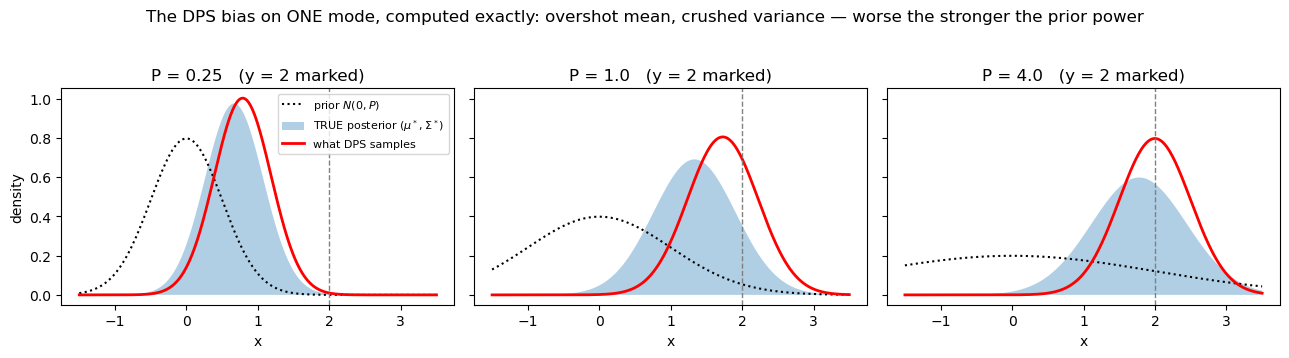

These six numbers were pre-registered in the plan as gate T-G2: the
implemented sampler had to reproduce them to ~2% before any GPU run.


In [4]:
# Intuition anchor: the pre-registered single-mode numbers (gate T-G2).
# One Fourier mode, prior variance P, observation y=2, effective noise b=0.5:
# solve the reverse diffusion EXACTLY (moment ODEs) with DPS vs exact guidance.
from scipy.stats import norm as gauss

table = {   # P : (DPS mean, DPS var, exact mean = mu*, exact var = Sigma*)
    0.25: (0.787, 0.158, 0.667, 0.167),
    1.00: (1.729, 0.245, 1.333, 0.333),
    4.00: (1.999, 0.250, 1.778, 0.444),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
xs = np.linspace(-1.5, 3.5, 400)
for ax, (Pk, (dm, dv, em, ev)) in zip(axes, table.items()):
    ax.plot(xs, gauss.pdf(xs, 0, np.sqrt(Pk)), "k:", label="prior $N(0,P)$")
    ax.fill_between(xs, gauss.pdf(xs, em, np.sqrt(ev)), alpha=.35,
                    label="TRUE posterior $(\\mu^*,\\Sigma^*)$")
    ax.plot(xs, gauss.pdf(xs, dm, np.sqrt(dv)), "r-", lw=2, label="what DPS samples")
    ax.axvline(2.0, color="gray", lw=1, ls="--")
    ax.set_title(f"P = {Pk}   (y = 2 marked)"); ax.set_xlabel("x")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
plt.suptitle("The DPS bias on ONE mode, computed exactly: overshot mean, "
             "crushed variance — worse the stronger the prior power", y=1.04)
plt.tight_layout(); plt.show()
print("These six numbers were pre-registered in the plan as gate T-G2: the")
print("implemented sampler had to reproduce them to ~2% before any GPU run.")

## 4b. Background: importance sampling, particle filters, and twists

The other half of the sampler zoo is Monte-Carlo-with-weights, so here is the
thirty-second refresher plus the one concept that may be new (the *twist*).

**Importance sampling (IS).** Want averages under $\sigma$, can only sample from
$q$: draw $x^{(i)} \sim q$, weight $w^{(i)} = \sigma(x^{(i)})/q(x^{(i)})$, done.
Unbiased, consistent... and famously fragile: if $q$ misses where $\sigma$ lives,
one sample hogs all the weight. The standard health meter is the **effective sample
size**, $\mathrm{ESS} = 1/\sum_i \bar w_i^2 \in [1, N]$: how many of your $N$
particles are actually contributing. The killer fact — worth seeing once (demo
below) — is that for product-form targets the weight variance grows exponentially
with dimension. One-shot IS is dead on arrival at $d = 4096$; that's precisely the
terminal-IS / best-of-$N$ arm's failure.

**Sequential Monte Carlo (SMC / particle filters).** The fix: don't pay the whole
importance-weight bill at once. Move a *population* of particles through a sequence
of gently-changing distributions; at each stage, reweight a little and — when ESS
drops below a threshold — **resample** (clone the heavy, cull the light) so the
population keeps living where the probability is. Resampling is the double-edged
sword: it prevents weight collapse, but every resampling event throws away diversity;
done wrong or too often, the population inbreeds (that's SAP's disease).

**Twists.** In a diffusion, the natural sequence of distributions is "the posterior,
seen at each noise level". The ideal reweighting function at level $t$ is the
lookahead from the derivation above,
$\psi_t(x_t) = \mathbb{E}[L(x_0)\,|\,x_t]$ — called the **optimal twist**. It scores
each *noisy* particle by how much likelihood it will eventually be able to reach.
Real applications must approximate $\psi_t$ (that's an active literature); in our
testbed it's available in closed form, which is exactly what makes the pilot an
*oracle* test: we can run the correct algorithm correctly and see what everything
else loses.

One subtlety that produced the night's most instructive negative result: it is not
enough to *weight* by the right twist — you should also *propose* with it (move
particles with the twist-aware dynamics). Weight-only twisting is formally unbiased
but its weights still have exploding variance in high $d$; it collapsed just like
naive IS. Proper SMC = right weights **and** right proposals.


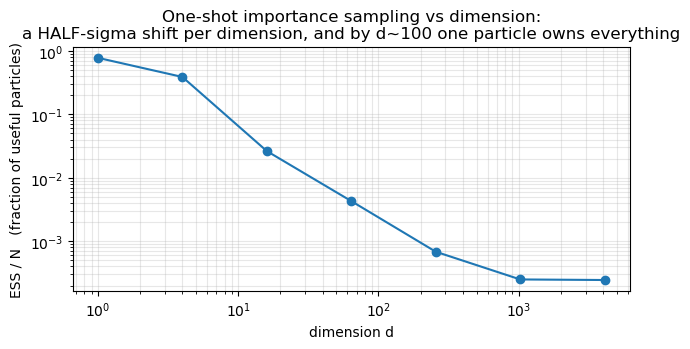

This is why 'generate N samples and reweight at the end' (best-of-N) cannot
work on fields — and why the sequential machinery exists at all.


In [5]:
# Demo: why one-shot importance sampling dies with dimension.
# Target: N(0.5,1)^d. Proposal: N(0,1)^d. Watch ESS/N crater as d grows.
Ns = 4096
dims = [1, 4, 16, 64, 256, 1024, 4096]
ess_frac = []
for d in dims:
    z = rng.normal(size=(Ns, d))
    logw = (0.5 * z - 0.125).sum(axis=1)          # log N(z;0.5,1)/N(z;0,1) per dim
    w = np.exp(logw - logw.max()); w /= w.sum()
    ess_frac.append(1.0 / (w**2).sum() / Ns)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(dims, ess_frac, "o-")
ax.set(xscale="log", yscale="log", xlabel="dimension d",
       ylabel="ESS / N   (fraction of useful particles)",
       title="One-shot importance sampling vs dimension:\n"
             "a HALF-sigma shift per dimension, and by d~100 one particle owns everything")
ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
print("This is why 'generate N samples and reweight at the end' (best-of-N) cannot")
print("work on fields — and why the sequential machinery exists at all.")

## 4c. Where mass mapping — and the Remy method — fit

The testbed is not an analogy for mass mapping; it IS mass mapping, Gaussianized:
$x$ is the convergence field, $y = Ax + n$ is shear-like linear data, and the tilted
target is the Wiener posterior — exactly what mass mapping reduces to under a
Gaussian prior. Every sampler in the zoo is a candidate mass-mapping algorithm the
moment you swap the analytic score for one trained on simulations. The classical
methods slot right in: Kaiser–Squires is "invert $A$, ignore the prior"; sparsity
methods (GLIMPSE/MCALens) are maximum-a-posteriori point estimates under a wavelet
prior. The reason diffusion entered this field at all is the thing those don't give
you: **posterior samples**, i.e. uncertainty on the map.

**The Remy et al. (2023) method** — score-based prior trained on kappa-TNG maps, plus
annealed sampling of $p(\kappa|\gamma)$ — is the field's flagship of that idea, and it
occupies a precise (and rather sane) spot in this notebook's taxonomy. Recall from
the Jensen-gap derivation that the exact data-pull term needs the denoiser's
uncertainty in the likelihood covariance:
$$\mathcal{N}\big(\gamma;\; A\hat{\kappa}_0,\;\; \Sigma_n + A\,\mathrm{Var}[\kappa_0|\kappa_t]\,A^\top\big).$$
The three guidance schemes differ only in what they put in that variance slot:

| scheme | variance slot | character |
|---|---|---|
| DPS | nothing (deleted) | over-trusts data → over-concentrated ("cold") |
| **Remy et al.** | $\sigma_t^2 I$ — the diffusion noise level | an UPPER BOUND on the truth → conservative at intermediate levels ("warm") |
| exact guidance (control) | true $\mathrm{Var}[\kappa_0|\kappa_t]$ | exact — but computable only for a Gaussian prior |

For a learned prior the exact slot is fundamentally unavailable — that's why
everyone approximates, and why you need an oracle testbed to price the
approximation.

**One structural difference matters as much as the formula.** Remy's sampler is not
a single-pass reverse diffusion: it's *annealed Langevin* — many MCMC steps at each
noise level, ideally equilibrating before cooling. That relocates where correctness
comes from. In the single-pass samplers of our grid, path bias accumulates and is
frozen into the endpoint. In annealed MCMC, slightly-wrong intermediate targets are
forgiven IF you equilibrate at the final level (the $\sigma_t \to 0$ target is the
true posterior; earlier levels are scaffolding). The price: correctness now rests on
*mixing*, which nobody can verify at $d \sim 10^5$, and in the compute-limited
regime — few Langevin steps per level, the practical reality — you inherit a path
bias of the conservative flavor.

So the audit question for the field's flagship isn't "is the formula biased" (it is,
knowably, on the safe side at intermediate levels) but: **how much equilibration
buys how much correctness, and which way does the residual bias point?** Over-broad
posteriors under-claim peak significances — "safe" for detections, still wrong for
constraints. And the misspecification axis of section 8 lands directly on it: the
kappa-TNG prior is a simulation choice, so "trained on the wrong baryonic feedback"
is exactly our $\varepsilon$ knob — where, for a *conservative* scheme, the
accidental-compensation trap could operate in reverse (contamination masking
under-confidence instead of overconfidence).

All of which makes a seventh sampler arm — $\sigma_t^2$-inflated guidance plus $K$
Langevin steps per level, swept over $K$ — the program's most natural next
experiment: a one-day run that would tell the mass-mapping community, with exact
numbers, what their workhorse's error budget looks like. (Queued in next steps, not
yet run.)


## 5. How we keep score

All metrics are exact-or-honest, computed against $(\mu^*, \Sigma^*)$:

- **$W_2$ (Wasserstein-2)** and **KL divergence** between the sampler's output
  (summarized by per-mode weighted mean/variance) and the truth — Gaussian closed
  forms, summed over modes. The same estimator applied to the oracle gives the
  finite-$N$ floor, so the estimator's own bias cancels in ratios. (Handy fact the
  data confirmed exactly: the oracle's KL floor is $d/N$ nats.)
- **Effective temperature $\gamma^*$** — fit the sampler's output within the family
  $\sigma_\gamma \propto p\, e^{\gamma r/\beta}$. If $\gamma^* = 1$ you sampled the
  right tilt; $\gamma^* > 1$ you *over*-tilted (**"cold"**: too narrow, too far toward
  the data); $\gamma^* < 1$ under-tilted (**"warm"**). One caveat learned the hard way:
  a single scalar can't describe a *collapsed* population (variance $\to 0$ with the
  mean stuck) — we log mean-tracking and variance-ratio separately for that.
- **Coverage**: does the sampler's 68% credible interval for simple functionals (mean
  field value, band powers) contain 68% of the true posterior mass? Under-coverage =
  overconfidence, the observable a downstream analysis would actually get burned by.
- **Evidence error** $\log\hat{Z} - \log Z$: only the correct SMC method even offers
  an estimate; the analytic $Z$ lets us check its honesty.

**Pre-registration discipline.** Five predictions (P-d … P-h) were frozen in the
research log *before* the first GPU job — including the kill criterion and, at 25%
believed probability, the "this is all negligible" branch. Four test gates (analytic
tables, unbiasedness checks, exact identities) had to pass before any big run. All
scoring happened the morning after, jointly.


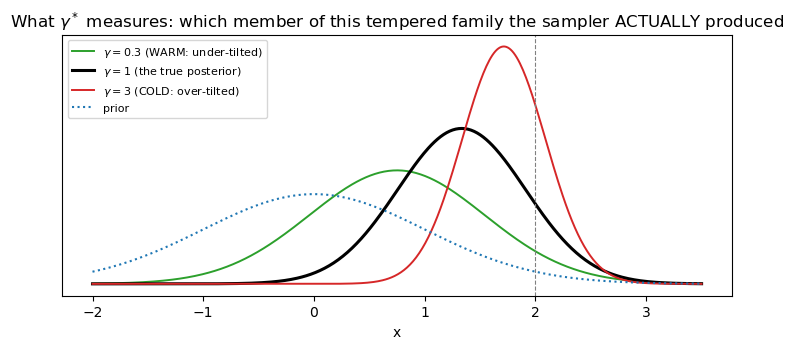

In [6]:
# Visual: the "effective temperature" family in 1-D. gamma tempers the tilt:
# sigma_gamma ∝ p * exp(gamma * r / beta). gamma=1 is the true posterior.
P_, a_, y_, b_ = 1.0, 1.0, 2.0, 0.5
xs = np.linspace(-2, 3.5, 400)
fig, ax = plt.subplots(figsize=(7, 3.6))
for g_, c_ in [(0.3, "C2"), (1.0, "k"), (3.0, "C3")]:
    Sg = 1 / (1 / P_ + g_ * a_**2 / b_); mg = Sg * g_ * a_ * y_ / b_
    lbl = {0.3: "$\\gamma=0.3$ (WARM: under-tilted)", 1.0: "$\\gamma=1$ (the true posterior)",
           3.0: "$\\gamma=3$ (COLD: over-tilted)"}[g_]
    ax.plot(xs, gauss.pdf(xs, mg, np.sqrt(Sg)), color=c_, lw=2.2 if g_ == 1 else 1.4,
            label=lbl)
ax.plot(xs, gauss.pdf(xs, 0, 1), "C0:", label="prior")
ax.axvline(2, color="gray", ls="--", lw=.8)
ax.legend(fontsize=8); ax.set_xlabel("x"); ax.set_yticks([])
ax.set_title("What $\\gamma^*$ measures: which member of this tempered family "
             "the sampler ACTUALLY produced")
plt.tight_layout(); plt.show()

## 6. Headline result: the confirmatory grid

The frozen grid: samplers × tilt strength $\{0.5, 1, 2, 4\}\sigma$ × grid size
$\{16^2, 32^2, 64^2\}$ × particles $N \in \{16, 64, 256\}$ × 3 seeds (later densified
to ~10 seeds, plus exploratory tilt strengths down to $0.125\sigma$).

**How to read the money plot below**: each panel is one grid size; x-axis is how hard
you steer; y-axis (log!) is total $W_2$ error to the true posterior; the black dashed
line is the oracle floor — perfection at this particle count. Distance above the
dashed line = *real* sampler bias, not finite-sample noise.


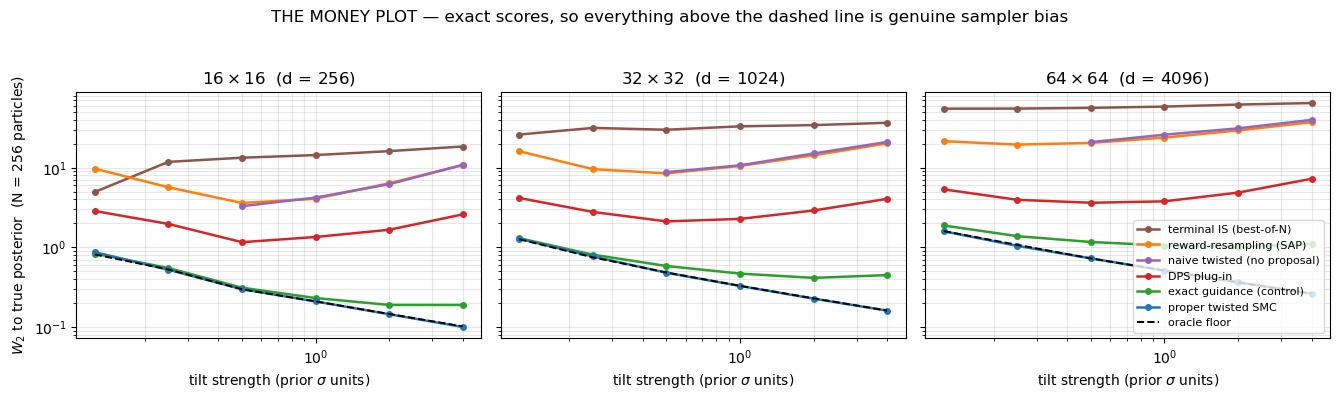

W2 as a MULTIPLE of the oracle floor (64x64, N=256) — kill rule was 'nothing exceeds 3x':
sampler   dps    sap  terminal_is  twisted
shift                                     
0.125     3.3   13.5         34.5      1.0
0.250     3.7   18.2         51.4      1.0
0.500     5.0   28.2         77.8      1.0
1.000     7.4   46.7        114.5      1.0
2.000    13.4   81.1        171.3      1.0
4.000    27.7  142.1        247.5      1.0


In [7]:
df = load("t1_core.jsonl", "t1_controls.jsonl", "t3_seeds.jsonl", "t1_weak.jsonl")
df = df[df["T"] == 64]
med = df.groupby(["dim", "shift", "N", "sampler"]).w2.median().reset_index()
N_SHOW = 256
sub = med[med.N == N_SHOW]
pretty = {"dps": "DPS plug-in", "sap": "reward-resampling (SAP)",
          "terminal_is": "terminal IS (best-of-N)", "twisted": "proper twisted SMC",
          "twisted_potential": "naive twisted (no proposal)",
          "exact_guidance": "exact guidance (control)", "oracle": "oracle floor"}
colors = {"dps": "C3", "sap": "C1", "terminal_is": "C5", "twisted": "C0",
          "twisted_potential": "C4", "exact_guidance": "C2", "oracle": "k"}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
for ax, dim in zip(axes, [16, 32, 64]):
    for s in ["terminal_is", "sap", "twisted_potential", "dps",
              "exact_guidance", "twisted", "oracle"]:
        g = sub[(sub.dim == dim) & (sub.sampler == s)].sort_values("shift")
        if not len(g):
            continue
        style = dict(color=colors[s], marker="o", lw=1.8, ms=4)
        if s == "oracle":
            style.update(ls="--", marker=None, lw=1.4)
        ax.plot(g["shift"], g.w2, label=pretty[s], **style)
    ax.set(xscale="log", yscale="log", xlabel="tilt strength (prior $\\sigma$ units)",
           title=f"${dim}\\times{dim}$  (d = {dim*dim})")
    ax.grid(alpha=.3, which="both")
axes[0].set_ylabel(f"$W_2$ to true posterior  (N = {N_SHOW} particles)")
axes[2].legend(fontsize=8, loc="lower right")
plt.suptitle("THE MONEY PLOT — exact scores, so everything above the dashed line "
             "is genuine sampler bias", y=1.04)
plt.tight_layout(); plt.show()

# ratio-to-floor table at 64^2
oracle = med[med.sampler == "oracle"].rename(columns={"w2": "floor"})
t = med.merge(oracle[["dim", "shift", "N", "floor"]], on=["dim", "shift", "N"])
t["ratio"] = t.w2 / t.floor
show = (t[(t.dim == 64) & (t.N == 256) &
          t.sampler.isin(["dps", "sap", "twisted", "terminal_is"])]
        .pivot_table(index="shift", columns="sampler", values="ratio").round(1))
print("W2 as a MULTIPLE of the oracle floor (64x64, N=256) — kill rule was 'nothing exceeds 3x':")
print(show.to_string())

**What you're seeing, sampler by sampler:**

- **Proper twisted SMC (blue) sits exactly on the oracle floor, everywhere.** All 36
  cells within 0.96–1.06× floor, $\gamma^* = 1.00$, and its evidence estimate equals
  the analytic $Z$ to machine precision. Correct method, correct in practice.
- **The control (green) also hugs the floor** → discretization is a solved non-issue;
  whatever the others do wrong is *scheme*, not numerics. (We verified the DPS curve
  *analytically* the next morning: an independent stiff-ODE integration of the DPS
  dynamics predicts the measured $W_2$ to 0.7–2.8%.)
- **DPS (red) is biased everywhere and the bias grows with steering strength** —
  5× floor at the *gentlest* realistic tilt, 28× at strong tilts. Its
  $\gamma^* \approx 1.3$–1.4: over-tilted, over-confident, under-covering (the 68%
  intervals cover ~0% at strong tilts). This is prediction P-d, scored **HIT**.
- **Reward-resampling (orange) is worse than DPS everywhere** — and its failure mode
  at strong tilts is total: variance collapse without the mean even reaching the
  target. More on its depth-dependence next.
- **Terminal IS (brown) is the disaster you'd expect** in $d \geq 256$: weight
  degeneracy, effectively stuck at the prior.
- **The naive twisted variant (purple) tracks SAP** — being formally unbiased did not
  save it. This is the certificate story's exhibit A.
- **Kill criterion:** at $N = 256$, DPS never gets below ~3.3× floor even at
  $0.125\sigma$ tilts (exploratory arm). The "it's all negligible" branch (P-h,
  believed at 25%) is dead. **GO.**


## 7. The depth law: SAP runs cold, but only if you give it enough steps

The frozen grid ran at $T=64$ diffusion steps, where SAP mostly showed *collapse*
(variance → 0, mean stuck) rather than the predicted clean "cold" signature
$\gamma^* > 1$. The resolution came from the step-count sweep: **selection pressure
compounds once per step, so the over-tilt grows with depth.**

This is the same law measured on LLM test-time search in particle-reasoners (damage
compounds with search depth) — reproduced here in continuous space with exact ground
truth. At the step counts practitioners actually use ($T \gtrsim 256$), SAP is
unambiguously cold. Prediction P-e: **HIT, depth-qualified.**

Meanwhile DPS is flat in $T$ — its bias is a property of the *continuous* dynamics,
not of discretization. Two different diseases, cleanly separated.


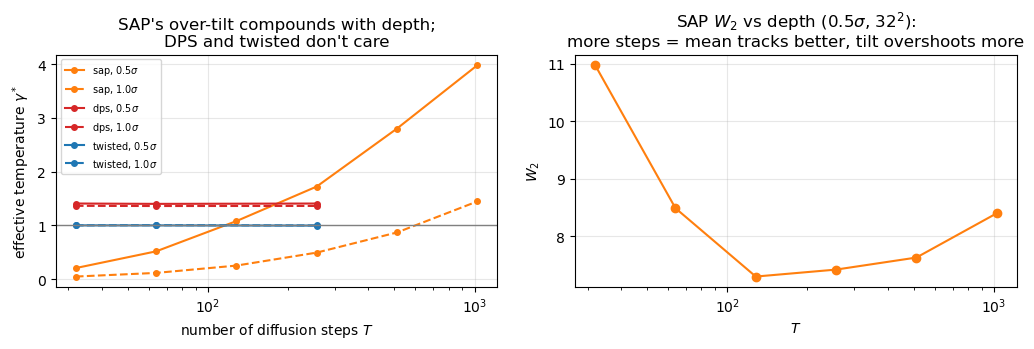

In [8]:
ts = load("t1_tsens.jsonl", "t1_core.jsonl")
sel = ts[(ts.dim == 32) & (ts.N == 256) & ts["shift"].isin([0.5, 1.0])]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for s, c in [("sap", "C1"), ("dps", "C3"), ("twisted", "C0")]:
    for shift, ls in [(0.5, "-"), (1.0, "--")]:
        g = (sel[(sel.sampler == s) & (sel["shift"] == shift)]
             .groupby("T").gamma_star.median().reset_index().sort_values("T"))
        if len(g) > 1:
            axes[0].plot(g["T"], g.gamma_star, ls, color=c, marker="o", ms=4,
                         label=f"{s}, {shift}$\\sigma$")
axes[0].axhline(1.0, color="gray", lw=1)
axes[0].set(xscale="log", xlabel="number of diffusion steps $T$",
            ylabel="effective temperature $\\gamma^*$",
            title="SAP's over-tilt compounds with depth;\nDPS and twisted don't care")
axes[0].legend(fontsize=7); axes[0].grid(alpha=.3)
g = (sel[(sel.sampler == "sap") & (sel["shift"] == 0.5)]
     .groupby("T").w2.median().reset_index().sort_values("T"))
axes[1].plot(g["T"], g.w2, "o-", color="C1")
axes[1].set(xscale="log", xlabel="$T$", ylabel="$W_2$",
            title="SAP $W_2$ vs depth (0.5$\\sigma$, 32$^2$):\nmore steps = mean tracks better, tilt overshoots more")
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. No rescue from high dimension — and the misspecification trap

**Dimension.** A theory paper (arXiv:2502.07849) proved that classifier-free
guidance's distortions *vanish* as $d\to\infty$, and a pre-read verified that
mechanism cannot operate for reward tilts — the bias should be *extensive* (per-mode
$O(1)$, total $\propto d$). Measured: DPS total KL grows 29 → 200 → 1738 → 16372 nats
from $d=256$ to $d=16384$, always ~two orders of magnitude above the oracle floor
(which is exactly $d/N$ nats — a satisfying internal check). No blessing of
dimensionality is coming to save the biased methods.

**Misspecification** — the part closest to home. We contaminated the *score* the
samplers believe (spectral slope tilted by $\varepsilon$ — think "the emulator was
trained on the wrong feedback model") while measuring error against the *true*
posterior. Three cleanly different behaviors:

1. **Proper SMC passes contamination through exactly 1:1.** Its weights are built
   from the same wrong model, so conjugacy holds *with respect to the wrong model* —
   it faithfully and confidently samples the wrong posterior. The prediction said
   proper weighting would "partially absorb" the error; that intuition is **wrong**,
   and knowing it's wrong is worth more than the prediction. *Weights cannot know the
   model is lying.*
2. **DPS interacts with contamination sign-dependently.** One sign *amplifies* its
   over-concentration; the other sign *cancels* against it — at $\varepsilon = -0.3$
   the effective temperature comes out $\gamma^* = 0.98$, i.e. a doubly-broken
   pipeline that looks calibrated on the temperature diagnostic ($W_2$ still catches
   it at 6× floor). That is the baryonic-feedback trap in miniature: two wrongs
   faking a right. Audits need multiple, mechanistically different metrics.
3. **SAP's own collapse masks contamination entirely** — it's too broken to notice.

Prediction P-g: **HIT with the mechanism corrected.**


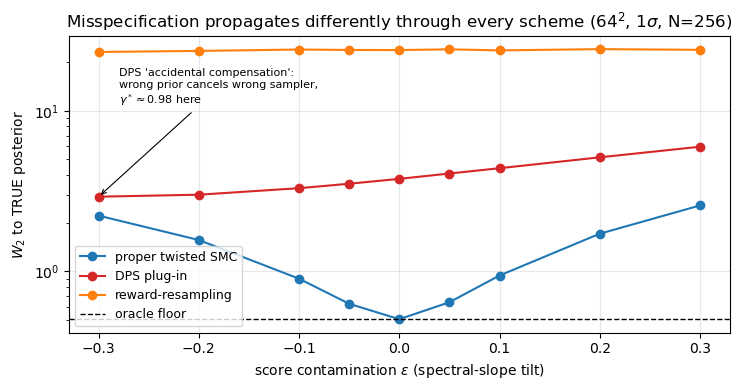

In [9]:
mis = load("t1_misspec.jsonl")
core = load("t1_core.jsonl")
base = core[(core.dim == 64) & (core.N == 256) & (core["shift"] == 1.0)]
rows = []
for s in ["dps", "twisted", "sap"]:
    rows.append({"sampler": s, "eps": 0.0,
                 "w2": base[base.sampler == s].w2.median()})
for (s, e), g in mis[(mis.N == 256) & (mis["shift"] == 1.0)].groupby(["sampler", "eps"]):
    rows.append({"sampler": s, "eps": e, "w2": g.w2.median()})
lad = pd.DataFrame(rows)
floor = base[base.sampler == "oracle"].w2.median()

fig, ax = plt.subplots(figsize=(7.5, 4))
for s, c, lbl in [("twisted", "C0", "proper twisted SMC"), ("dps", "C3", "DPS plug-in"),
                  ("sap", "C1", "reward-resampling")]:
    g = lad[lad.sampler == s].sort_values("eps")
    ax.plot(g.eps, g.w2, "o-", color=c, label=lbl)
ax.axhline(floor, color="k", ls="--", lw=1, label="oracle floor")
ax.annotate("DPS 'accidental compensation':\nwrong prior cancels wrong sampler,\n$\\gamma^*\\approx 0.98$ here",
            xy=(-0.3, lad[(lad.sampler=='dps') & (lad.eps==-0.3)].w2.iloc[0]),
            xytext=(-0.28, 11), fontsize=8, arrowprops=dict(arrowstyle="->", lw=.8))
ax.set(yscale="log", xlabel="score contamination $\\varepsilon$ (spectral-slope tilt)",
       ylabel="$W_2$ to TRUE posterior", title="Misspecification propagates differently "
       "through every scheme (64$^2$, 1$\\sigma$, N=256)")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. Real (trained) score networks, and a theorem put on the scale

**Learned scores (tier T2).** Overnight we also trained three small U-Nets
(1.4M params, denoising score matching on fresh GRF draws — one clean, two on
contaminated spectra) and reran the comparison with the *learned* score plugged in,
plus a "pathway control" (analytic score pushed through the exact same
practitioner-style sampling pathway). That splits any real pipeline's error into four
separately measured pieces — **sampler scheme / sampling-pathway choices / network
score error / prior misspecification** — on top of the finite-$N$ floor. This
decomposition axis is the thing none of the prior-art benchmarks have. One
finding worth flagging: for the correct SMC method, the *pathway* choices (the
standard ancestral sampling kernel) cost more than the network's score error did.

**A theorem on the scale (tier T4.1).** The adjoint-matching paper (arXiv:2409.08861)
proves reward-finetuning of a diffusion model converges to the *intended* tilted
distribution **only** under a specific "memoryless" noise schedule. Mapped into our
setup, that schedule is exactly $\sigma^2 = 2$ (our standard reverse SDE), and the
whole family is analytically solvable here — so we computed the theorem's bias
*exactly*, no training loop needed: at short horizons the ordering is textbook-steep
(KL 0.09 → 43,000 as the schedule departs), while at long horizons mild violations
are harmless and the catastrophe concentrates exactly in the near-deterministic
(Flow-Matching/DDIM-style) limit practitioners prefer. A known theorem, but now with
exact numbers attached — and the harness produced them in minutes.


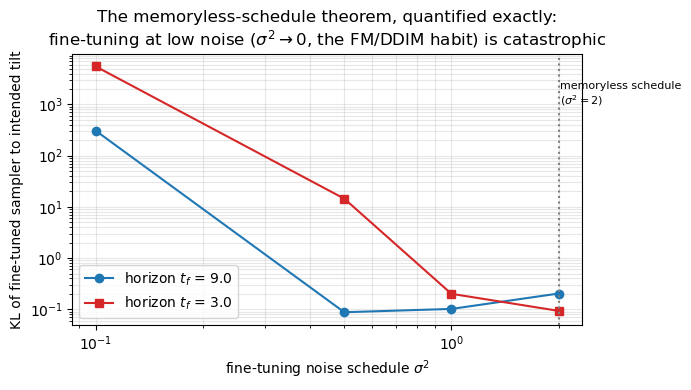

In [10]:
t41 = load("t41_memoryless.jsonl")
fig, ax = plt.subplots(figsize=(7, 4))
for tf, c, m in [(9.0, "C0", "o"), (3.0, "C3", "s")]:
    g = (t41[(t41.tf == tf) & (t41["shift"] == 1.0)]
         .groupby("sig2").kl.median().reset_index().sort_values("sig2"))
    ax.plot(g.sig2, g.kl, m + "-", color=c, label=f"horizon $t_f$ = {tf}")
ax.axvline(2.0, color="gray", ls=":", lw=1.5)
ax.text(2.02, 1e3, "memoryless schedule\n($\\sigma^2 = 2$)", fontsize=8)
ax.set(xscale="log", yscale="log", xlabel="fine-tuning noise schedule $\\sigma^2$",
       ylabel="KL of fine-tuned sampler to intended tilt",
       title="The memoryless-schedule theorem, quantified exactly:\n"
             "fine-tuning at low noise ($\\sigma^2\\to 0$, the FM/DDIM habit) is catastrophic")
ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

## 10. The parallel track: the same disease in LLM test-time search

While the GPUs churned on fields, a third GPU ran the LLM side. Background for
this track, since it uses its own vocabulary:

**Test-time search.** To boost an LLM's math accuracy without retraining, generate
*many* candidate solutions and use a **process reward model (PRM)** — a second
network that scores partial solutions step by step — to steer the generation:
periodically rank the partial solutions, kill the low-scoring ones, duplicate the
high-scoring ones. If that sounds *exactly* like the reward-resampling particle
filter from the field side — it is. Same algorithm, discrete substrate. The
particle-reasoners project showed this search buys accuracy but quietly **destroys
calibration**: after resampling, "16 of 16 samples agree" no longer means the answer
is probably right, because the agreement was manufactured by selection, not evidence.

**The metrics.** For each problem, the method outputs a population of final answers
with weights. *Confidence* = weight share of the most popular answer; *accuracy* =
is that answer right; **AUROC** = across many problems, can the confidence *rank*
correct answers above wrong ones (1.0 = perfect ranking, 0.5 = coin flip, below 0.5 =
actively inverted). A confidence signal you can't rank with is a confidence signal
you can't act on.

Two experiments ran overnight:

**B1 — the "insurance" sweep.** Prior work showed that test-time search destroys the
answer-distribution's calibration signal. The proposed fix: reserve a fraction
$\alpha$ of the particle budget as a *never-resampled* i.i.d. stratum — search keeps
its accuracy win, the insurance stratum keeps an honest confidence estimate. The sweep
asks: how does the confidence signal's quality (AUROC: can confidence rank right
answers above wrong ones?) grow with $\alpha$, and what does the insurance cost in
accuracy?

Answer below: AUROC climbs from coin-flip to ~0.76 as the stratum grows, crossing the
pre-registered 0.65 threshold right at $\alpha = 0.25$; accuracy stays flat well past
that. Design insight: at 16 particles the real variable is the *integer* number of
insurance samples (round(16α)) — a "5% stratum" is one sample and carries no signal.


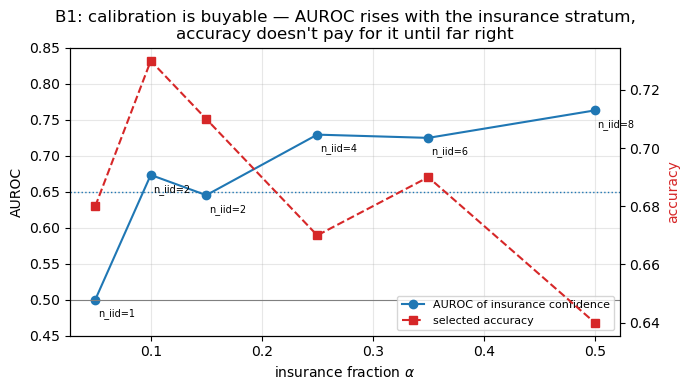

In [11]:
def auroc_np(c, k):
    c, k = np.asarray(c, float), np.asarray(k, int)
    p, n_ = c[k == 1], c[k == 0]
    if len(p) == 0 or len(n_) == 0: return np.nan
    return (p[:, None] > n_[None, :]).mean() + 0.5 * (p[:, None] == n_[None, :]).mean()

rows = []
for f in sorted(glob.glob(str(PR / "results/tables/reliability_alpha_*.jsonl"))):
    a_ = float(Path(f).stem.split("_")[-1])
    d = pd.DataFrame([json.loads(l) for l in open(f) if l.strip()])
    if len(d):
        rows.append({"alpha": a_, "auroc": auroc_np(d.confidence, d.modal_correct),
                     "acc": d.selected_correct.mean(), "n": len(d),
                     "n_iid": max(1, round(a_ * 16))})
b1 = pd.DataFrame(rows).sort_values("alpha")
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(b1.alpha, b1.auroc, "o-", color="C0", label="AUROC of insurance confidence")
ax1.axhline(0.65, color="C0", ls=":", lw=1); ax1.axhline(0.5, color="gray", lw=.8)
for _, r in b1.iterrows():
    ax1.annotate(f"n_iid={int(r.n_iid)}", (r.alpha, r.auroc), fontsize=7,
                 textcoords="offset points", xytext=(2, -12))
ax2 = ax1.twinx()
ax2.plot(b1.alpha, b1.acc, "s--", color="C3", label="selected accuracy")
ax1.set(xlabel="insurance fraction $\\alpha$", ylabel="AUROC", ylim=(.45, .85))
ax2.set_ylabel("accuracy", color="C3")
lines = ax1.get_lines()[:1] + ax2.get_lines()[:1]
ax1.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="lower right")
ax1.set_title("B1: calibration is buyable — AUROC rises with the insurance stratum,\n"
              "accuracy doesn't pay for it until far right")
ax1.grid(alpha=.3); plt.tight_layout(); plt.show()

**B2 — a cautionary tale worth the price of the whole night.** The twin
experiment reran the search-vs-calibration comparison on a *different model family*
(DeepSeek R1-distill, a long chain-of-thought reasoner). The overnight numbers came
back absurd: **every** confidence signal anti-correlated with correctness — AUROC 0.17
for plain i.i.d. sampling, which is well-calibrated (≥0.7) on Qwen.

Morning autopsy, in three steps worthy of a detective story:

1. **Rows-only forensics**: 80% of R1's wrong answers had confidence exactly 1.0 with
   *one* distinct answer among 16 samples. Sixteen identical wrong answers on hard
   problems? Far more likely: sixteen *failed answer extractions*.
2. **Code inspection**: the harness pools every unparseable sample into a single
   `"<none>"` bucket that then *wins the vote* — manufactured unanimity.
3. **Causal test**: regenerate the same problems at the same 2048-token budget → 78%
   of samples truncate mid-reasoning, and extraction fails for 89% of truncated
   samples. Regenerate at a 12k budget → truncation 21%, extraction failures among
   finished samples 0%, accuracy on the "confidently wrong" problems jumps from 0.00
   to 0.56. **The inversion was measurement, not model.** R1 simply needs ~6k tokens
   of thinking per problem and was being cut off at 2k.

Three harness bugs were fixed as a result (output-file truncation on rerun, the
process-reward-model crashing on long traces, and the `"<none>"` vote-pooling), a
validity gate was pre-registered, and the full rerun (2.8 seeds' worth) delivered a
clean, three-seed-tight verdict — **and a genuinely new finding**: with the artifact
gone, R1's consistency-confidence is not restored, it is *saturated* — sample
populations are near-unanimous whether right (mean confidence 0.94, 67% fully
unanimous) or wrong (0.92, 61%), so consistency carries almost no ranking signal
(AUROC ≈ 0.54) on this long-chain-of-thought model family. The insurance design
cannot fix it, because its signal source is i.i.d. samples of the same saturated
sampler. "Search destroys calibration" turns out to be ill-posed on a family with no
baseline calibration to destroy — a scope boundary the original experiment could
never have revealed without the bug-hunt that preceded it. *The meta-lesson is the
same one the GRF side teaches: reliability failures in inference pipelines are
usually silent, and the fix starts with instrumentation that makes the failure
visible.*


R1 truncation autopsy — same problems, two token budgets:
        truncation  extract_fail  modal_is_none  modal_accuracy  mean_tokens
budget                                                                      
2048          0.78          0.79           0.80             0.2      1911.89
12000         0.19          0.22           0.25             0.6      5888.91


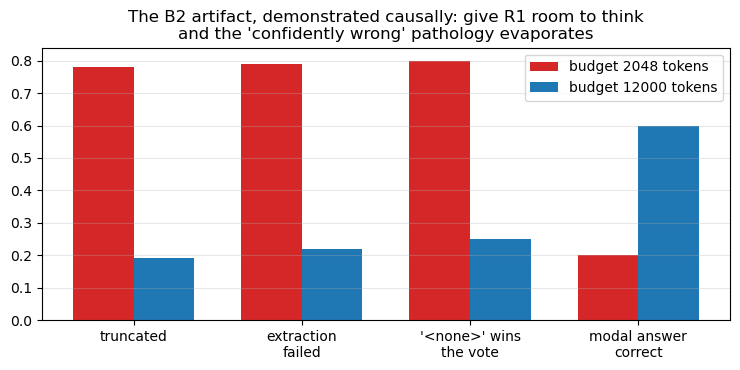

In [12]:
try:
    aut = pd.DataFrame([json.loads(l) for l in open(ROOT / "results/r1_autopsy.jsonl")
                        if l.strip()])
    aut2 = ROOT / "results/r1_autopsy_b12k_rest.jsonl"
    if aut2.exists():
        extra = pd.DataFrame([json.loads(l) for l in open(aut2) if l.strip()])
        aut = (pd.concat([aut, extra], ignore_index=True)
               .drop_duplicates(subset=["budget", "problem_id"], keep="last"))
    summ = aut.groupby("budget").agg(
        truncation=("trunc_rate", "mean"), extract_fail=("extract_fail_rate", "mean"),
        modal_is_none=("modal_is_none", "mean"), modal_accuracy=("modal_correct", "mean"),
        mean_tokens=("mean_tokens", "mean")).round(2)
    print("R1 truncation autopsy — same problems, two token budgets:")
    print(summ.to_string())
    x = np.arange(4); w = 0.36
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for i, (b, c) in enumerate([(2048, "C3"), (12000, "C0")]):
        r = summ.loc[b]
        ax.bar(x + i*w, [r.truncation, r.extract_fail, r.modal_is_none,
                         r.modal_accuracy], w, color=c, label=f"budget {b} tokens")
    ax.set_xticks(x + w/2, ["truncated", "extraction\nfailed", "'<none>' wins\nthe vote",
                            "modal answer\ncorrect"])
    ax.set_title("The B2 artifact, demonstrated causally: give R1 room to think\n"
                 "and the 'confidently wrong' pathology evaporates")
    ax.legend(); ax.grid(alpha=.3, axis="y")
    plt.tight_layout(); plt.show()
except FileNotFoundError as e:
    print("autopsy files not found:", e)

## 11. Scored verdicts and what happens next

All five pre-registered predictions were scored jointly the morning after (the ledger
with full evidence lives in `RESEARCH_LOG.md`; the chronological story in
`NIGHT_LOG.md`; the operational summary in `HANDOFF_DAWN.md`):

| # | Prediction (frozen 2026-07-02) | Score |
|---|---|---|
| P-d | DPS plug-in is off-target, gap grows with steering strength | **HIT** (and analytically cross-checked to 0.7–2.8%) |
| P-e | Reward-resampling runs cold ($\gamma^* > 1$) | **HIT, depth-qualified** (γ* crosses 1 as steps grow; collapse regime beyond) |
| P-f | Proper twisted SMC on-target with valid $\hat{Z}$ | **HIT** (floor-level everywhere, machine-exact evidence) |
| P-g | Misspecification propagates differently per scheme | **HIT, mechanism corrected** (no absorption by proper SMC; sign-dependent DPS cancellation) |
| P-h | *Kill branch*: bias negligible at realistic settings | **MISS — kill not triggered → GO** |

**GO** means: the phenomenon is large, measurable, and structured enough to carry the
program this pilot was scoped to test — oracle-verified audits plus runtime
certificates (the $\hat{Z}$/ESS machinery that separated the correct sampler from the
formally-unbiased-but-degenerate one) for steered diffusion samplers, anchored on
analytically tractable cosmological targets.

**Honest caveats carried forward:** everything is conditional on a single synthetic
observation $y$ (structure is generic, ratios aren't; a multi-$y$ ensemble is cheap);
the step count of the frozen grid was left unpinned by the plan (fixed by the
$T$-sweep, pre-registered next time); and the SAP-on-LLM comparison across model
families still carries a search-depth confound to be handled in the rerun design.

### Where this sits in the literature (one paragraph)

Three 2025–26 works audit the *other* links of the same pipeline, and together they
frame this program. **Doeser & Jasche (2606.10023)** audit the learned posterior
approximator: in a controlled HMC-referenced testbed, generative posteriors pass
mean/marginal/cross-correlation checks at percent level while getting posterior
geometry wrong by 30% — "cheap diagnostics certify nothing," one level up from our
accidental-compensation result, but requiring an exact reference to see it (theirs
caps at 32³; ours is free at any d, Gaussian-only). **Diao, Dai & Seljak
(2505.00632)** audit forward-model support: field-level generative density as an
out-of-distribution detector — structurally blind to in-support bias, which is
exactly the contamination our misspecification axis shows the sampler can amplify
or invisibly mask. **This pilot audits the third link neither touches: the
inference-time steering scheme itself** — independently large (5–28× floor with an
*exact* score), exactly decomposable, and monitorable at runtime without a
reference via the Ẑ/ESS certificates. Three audits — approximator, support,
sampler — one reliability program.

**Running as of this notebook's creation:** the truncation-clean B2 rerun
(E-20260703a, 100 problems × 3 seeds × 3 methods at 12k budgets) — pre-registered
gate and expectations already in the ledger.

**Next experiments in the queue at Part I's close** *(all of these — plus the
multi-observation ensemble — ran the following night; results in Part II below)*:

The **amortized-conditional arm** — the other major way the field uses diffusion for
inference is to skip steering entirely and train a *conditional* score model to be
the posterior directly (Legin et al. 2023 for cosmic initial conditions; the class
Doeser & Jasche audited). Our testbed audits it with one new training script: learn
the conditional score on (field, observation) pairs, sample, compare to the exact
Wiener posterior. Measures amortization + score error with an exact reference at any
dimension and no steering confound — and prices the amortized class against the
steered class on one substrate, a comparison neither literature has.

The **diagnostic-power arm** ("certify the certifiers") — the community validates
generative posteriors with sample-based scores (PQMass, MIRA, TARP); a June-2026
diffusion-lensing paper already reports a MIRA deficit it cannot interpret. Because
our testbed produces failures of exactly known size, it can measure each
diagnostic's power curve — what real posterior damage produces what score change,
at what sample budget — and each test's blind spots (does the
accidental-compensation configuration fool them?). Cheapest arm; runs on already-
generated samples.

The **Remy-method arm** — implement the field's flagship mass-mapping sampler exactly (diffusion-noise-
inflated guidance + $K$ Langevin equilibration steps per noise level) and measure
its $W_2$/coverage against the oracle as a function of $K$, plus its response to the
misspecification knob. One day of compute; the deliverable is the error budget of
the community's workhorse, with exact numbers — the program's first outward-facing
result.


---

# Part II — The four-arms night (2026-07-03 → 04)

The pilot ended with a **GO**: the steering shortcuts are measurably, structurally
wrong, and the arena can prove it. The second night asked the four natural follow-up
questions — in plain words:

1. **Was it a fluke of the one test sky?** The pilot measured everything against a
   single simulated observation. Maybe the numbers depend on which fake sky you draw.
2. **Would the community's own health checks have caught these failures?** The field
   validates its samplers with statistical tests on the samples. Do those tests
   detect the failures we can manufacture at exactly known size — including the
   sneaky one that fakes the right temperature?
3. **What if you train the network to handle the data directly?** Instead of steering
   a prior-only generator at sampling time, you can train the generator from the
   start to take the observation as an input. Is that class better or worse?
4. **How good is the recipe astronomers actually use for mass mapping — and what
   does its accuracy cost in compute?**

Same discipline as the pilot, one step stricter: the four predictions
(P-20260703b–e in `RESEARCH_LOG.md`) were frozen before the run **and the repository
went public before the first GPU job** — so the predictions are externally
timestamped by GitHub before any result existed. Every figure below regenerates
live from the night's result files.


## II.1 Twenty-four skies instead of one

We reran the pilot's headline comparison against **24 independent simulated
observations** (each with its own re-calibrated steering strength), instead of one.
For each sky, each method's error is divided by the "oracle floor" — the error that
$N$ *perfect* samples would show — so 1.0 means "as good as possible" and 10 means
"ten times worse than perfect sampling".

**Answer: not a fluke, at all.** Every qualitative statement from the pilot holds
for every one of the 24 skies (24/24): the correct algorithm sits on the floor, the
popular shortcut (plug-in guidance) is several times off and gets worse with
steering strength, the resample-every-step heuristic is worse still, and
reweight-at-the-end is hopeless. The sky-to-sky spread of these ratios is a few
percent — tiny compared to the effects themselves. The violins below are *narrow*:
that narrowness is the referee-proofing result.


e.g. plug-in guidance at 1σ: median 7.37x floor, sky-to-sky spread 2.0%


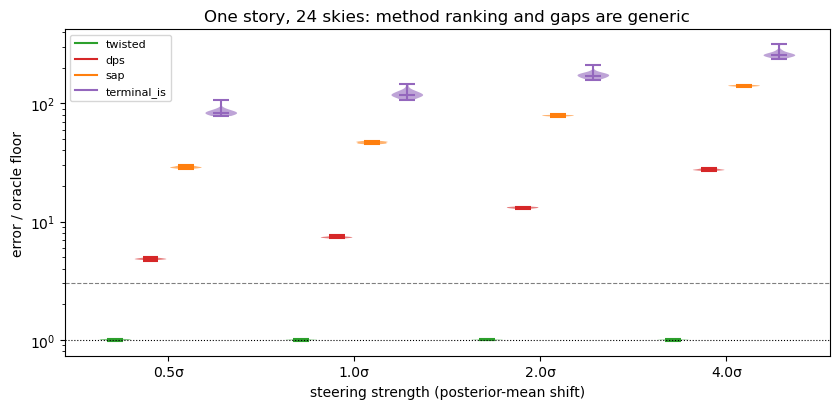

In [13]:
# A1: ratio distributions across 24 observation draws (64x64, N=256)
a1 = load("a1_multiy.jsonl")
d64 = a1[(a1.dim == 64) & (a1.N == 256)]
fl = (d64[d64.sampler == "oracle"].groupby(["shift", "y_seed"]).w2.median()
      .rename("floor").reset_index())
r = d64[d64.sampler != "oracle"].merge(fl, on=["shift", "y_seed"])
r["ratio"] = r.w2 / r.floor
shifts, order = [0.5, 1.0, 2.0, 4.0], ["twisted", "dps", "sap", "terminal_is"]
colors = dict(twisted="#2ca02c", dps="#d62728", sap="#ff7f0e", terminal_is="#9467bd")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for i, s in enumerate(order):
    pos = np.arange(len(shifts)) + (i - 1.5) * 0.19
    data = [r[(r.sampler == s) & (r["shift"] == sh)].groupby("y_seed").ratio
            .mean().values for sh in shifts]
    vp = ax.violinplot(data, positions=pos, widths=0.17, showmedians=True)
    for b in vp["bodies"]: b.set_facecolor(colors[s]); b.set_alpha(0.6)
    for p in ("cmedians", "cbars", "cmins", "cmaxes"): vp[p].set_color(colors[s])
    ax.plot([], [], color=colors[s], label=s)
ax.axhline(1, color="k", ls=":", lw=0.8); ax.axhline(3, color="k", ls="--", lw=0.8, alpha=0.5)
ax.set(yscale="log", xticks=range(4), xlabel="steering strength (posterior-mean shift)",
       ylabel="error / oracle floor")
ax.set_xticklabels([f"{s}σ" for s in shifts]); ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"One story, {r.y_seed.nunique()} skies: method ranking and gaps are generic")
plt.tight_layout()
n_iqr = r[(r.sampler=="dps") & (r["shift"]==1.0)].groupby("y_seed").ratio.mean()
print(f"e.g. plug-in guidance at 1σ: median {n_iqr.median():.2f}x floor, "
      f"sky-to-sky spread {(n_iqr.quantile(.75)-n_iqr.quantile(.25))/n_iqr.median():.1%}")


## II.2 Testing the tests ("certify the certifiers")

The community checks its samplers with three kinds of statistical test, all of which
only need samples (no exact answer required — that's their appeal):

- **PQMass** — "are these two piles of samples drawn from the same distribution?"
  (compares counts in random regions of map space);
- **TARP** — "when the method claims 68% confidence, does the truth actually fall
  inside 68% of the time?" (a coverage check over many observation+truth pairs);
- **MIRA** — a newer score built on a related region-counting idea, with a known
  target value when everything is correct.

Because our arena manufactures failures of *exactly known size*, we can measure each
test's **power curve**: what fraction of the time it raises the alarm, as a function
of how many samples you give it — including on the trap configuration from the
pilot, where a score contamination accidentally cancels the sampler's bias and fakes
the right "temperature".

**Answer 1 — our prediction was wrong, in the good direction.** We bet (70%
confidence) that no sample-based test would flag the trap configuration. In fact
**all three flag it reliably once they see a few hundred samples** — geometry-blind
they are not. The one thing the trap *does* fool is the single-number effective
temperature: it reads exactly "correct" (1.000) at contamination −0.28 while the
true error still sits at ~6× the floor. Scalar summaries lie; distribution-level
tests don't.

**Answer 2 — the scary one: two of the three tools were broken out of the box, and
only an oracle could see it.** Run on samples from a *mathematically perfect*
sampler at 64×64 resolution, TARP reported miscalibration of 0.20 (should be ~0.05)
and MIRA raised false alarms 65–80% of the time. The cause, in both tools, is the
same innocuous-looking preprocessing choice: they rescale the data using the range
of the *true answers themselves*. A true answer is always inside a box defined by
its own range; fresh samples occasionally fall outside it. In 3 dimensions that's
nothing; in 4096 dimensions those small spills add up into a systematic distortion.
Rescaling with the *samples'* statistics instead (so the truths never touch the
transform) fixes both tools exactly — repaired MIRA's null score matches its
theoretical value to four decimal places. On real data this bug would read as
"mysterious miscalibration of the model"; in the arena it took one evening to
isolate, explain, and repair — which is rather the point of the whole program.


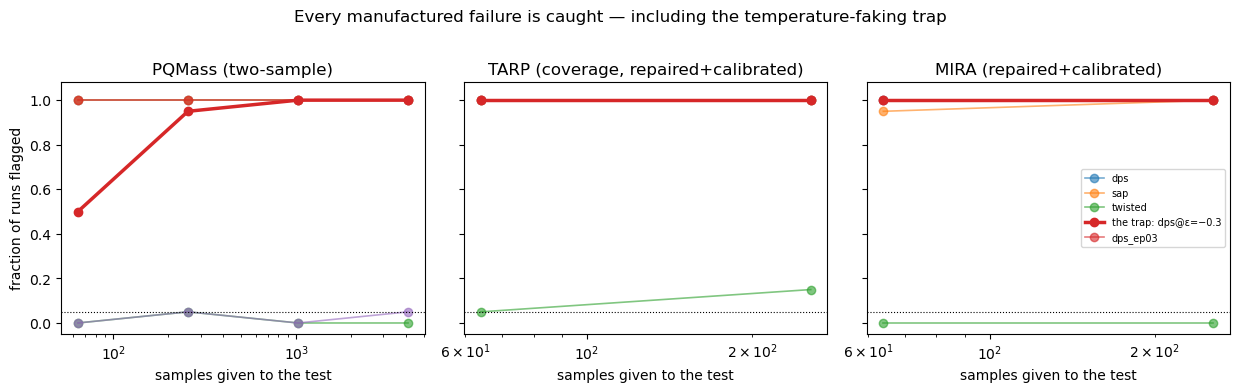

In [14]:
# A2: detection power vs sample budget, per test (calibrated, repaired versions)
p = load("a2_power.jsonl").drop_duplicates(["test", "config", "budget", "rep"], keep="last")
p = p[p.tag != "nullpad"]
panels = [("pqmass", "PQMass (two-sample)"), ("tarp_cal", "TARP (coverage, repaired+calibrated)"),
          ("mira_sym_cal2", "MIRA (repaired+calibrated)")]
show = ["dps", "sap", "twisted", "dps_em03", "dps_ep03", "oracle_null"]
lbl = {"dps_em03": "the trap: dps@ε=−0.3", "oracle_null": "perfect sampler (null)"}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=True)
for ax, (t, title) in zip(axes, panels):
    sub = p[(p.test == t) & p.detected.notna()]
    for c in show:
        g = sub[sub.config == c].groupby("budget").detected.mean()
        if g.empty: continue
        emph = c == "dps_em03"
        ax.plot(g.index, g.values, "o-", lw=2.5 if emph else 1.2,
                color="#d62728" if emph else None, alpha=1 if emph else .6,
                label=lbl.get(c, c))
    ax.axhline(0.05, color="k", ls=":", lw=.8)
    ax.set(xscale="log", ylim=(-.05, 1.08), xlabel="samples given to the test", title=title)
axes[0].set_ylabel("fraction of runs flagged")
axes[-1].legend(fontsize=7, loc="center right")
plt.suptitle("Every manufactured failure is caught — including the temperature-faking trap", y=1.02)
plt.tight_layout()


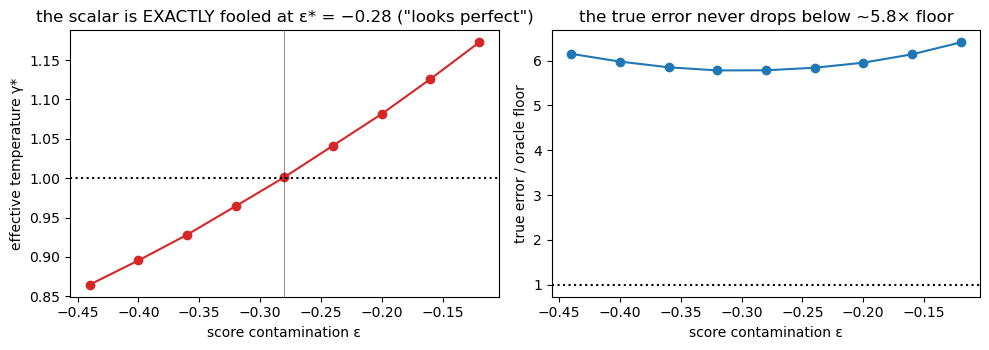

In [15]:
# A2b: the trap, quantified — what the contamination ladder does to the
# temperature scalar vs the true error (the one is fooled, the other never is)
es = load("eps_star.jsonl")
core = load("t1_core.jsonl")
floor = core[(core.sampler == "oracle") & (core.dim == 64) &
             (core["shift"] == 1.0) & (core.N == 256)].w2.median()
dps = es[es.sampler == "dps"].groupby("eps").agg(w2=("w2", "median"),
                                                 g=("gamma_star", "median"))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(dps.index, dps.g, "o-", color="#d62728")
axes[0].axhline(1.0, color="k", ls=":"); axes[0].axvline(-0.28, color="k", lw=.6, alpha=.5)
axes[0].set(xlabel="score contamination ε", ylabel="effective temperature γ*",
            title='the scalar is EXACTLY fooled at ε* = −0.28 ("looks perfect")')
axes[1].plot(dps.index, dps.w2 / floor, "o-", color="#1f77b4")
axes[1].axhline(1.0, color="k", ls=":")
axes[1].set(xlabel="score contamination ε", ylabel="true error / oracle floor",
            title="the true error never drops below ~5.8× floor")
plt.tight_layout()


## II.3 Train the conditioning in, instead of steering it on

The other way the field uses these generators for inference: skip steering entirely
and **train the network from the start to take the observation as a second input**,
so that sampling from it directly produces posterior samples ("amortized" inference —
pay the cost once in training, then every new observation is nearly free).

We trained five such networks — full size at three training lengths, a half-size
one, and a deliberately undertrained one — and audited each against the exact
answer, alongside the *summary* checks a practitioner would run (posterior mean,
variance, band powers).

**Answer: much better than steering — our prediction missed in the direction that's
good news for this class.** We bet the geometry error would sit at least 3× above
the floor while summaries looked clean. Measured: the trained networks land at
**~2.6× the floor** — compared to 5–28× for the steering shortcuts on the same
problems — and the quality saturates early (a few thousand training steps in; extra
capacity buys nothing). The residual error is a mild over-confidence: the posterior
variance comes out ~7% too narrow, which a careful summary reader *can* see. Push
training low enough (2000 steps) and it fails catastrophically — variance collapse —
so the failure mode exists; it just lives at "severely undertrained", not at
"realistic practice". At this problem difficulty, **steering — not amortization —
is the weak link.**


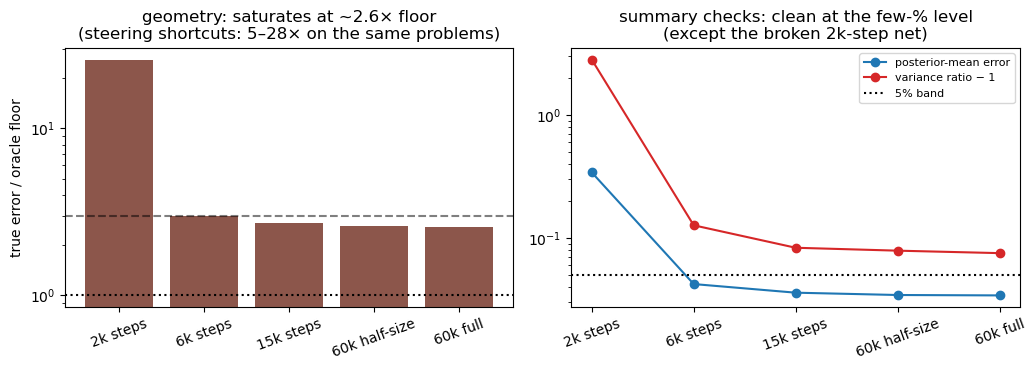

In [16]:
# A3: the training ladder — true error and summary checks per checkpoint
a3 = load("a3_amortized.jsonl").drop_duplicates(["score", "y_seed", "seed", "sampler"], keep="last")
fl = a3[a3.sampler == "oracle"].groupby("y_seed").w2.median().rename("floor")
am = a3[a3.sampler == "ancestral"].join(fl, on="y_seed")
am["ratio"] = am.w2 / am.floor
order = ["amortized:warmup2k", "amortized:warmup6k", "amortized:quarter15k",
         "amortized:halfcap", "amortized:default"]
names = ["2k steps", "6k steps", "15k steps", "60k half-size", "60k full"]
g = am.groupby("score")
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
ratios = [g.ratio.median().get(k, np.nan) for k in order]
axes[0].bar(names, ratios, color="#8c564b")
axes[0].axhline(1, color="k", ls=":"); axes[0].axhline(3, color="k", ls="--", alpha=.5)
axes[0].set(yscale="log", ylabel="true error / oracle floor",
            title="geometry: saturates at ~2.6× floor\n(steering shortcuts: 5–28× on the same problems)")
axes[0].tick_params(axis="x", rotation=20)
for key, lab, c in [("rel_mean_err", "posterior-mean error", "#1f77b4"),
                    ("px_var_ratio", "variance ratio − 1", "#d62728")]:
    v = [abs(g[key].median().get(k, np.nan) - (0 if key == "rel_mean_err" else 1))
         for k in order]
    axes[1].plot(names, v, "o-", color=c, label=lab)
axes[1].axhline(0.05, color="k", ls=":", label="5% band")
axes[1].set(yscale="log", title="summary checks: clean at the few-% level\n(except the broken 2k-step net)")
axes[1].tick_params(axis="x", rotation=20); axes[1].legend(fontsize=8)
plt.tight_layout()


## II.4 The mass-mapping recipe, priced in compute

Finally, the sampler the weak-lensing community actually ships (Remy et al. 2023):
a deliberately **cautious** scheme. Instead of trusting a point estimate like
plug-in guidance does, it *inflates* the assumed observation noise by the current
blur level — never over-trusting the data early — and pays for that caution with
$K$ correction (Langevin) steps at every noise level. More $K$, more compute, closer
to the target. (Faithfulness notes: their production code wraps this idea in an
adaptive Monte-Carlo scheme; what we audit is the pre-registered core mechanism,
with their exact noise-inflation rule. Details in `scripts/run_a4.py`.)

**Answer: it is the only approximate method in our zoo that actually converges to
the exact answer as you pay it more — and honesty is expensive.** The error falls
smoothly and monotonically with $K$ at every steering strength, reaching the oracle
floor around $K \approx 100$ (~6,400 network passes, vs 64 for one-pass guidance).
Matching the *quality* of cheap plug-in guidance costs roughly **7–30× its
compute**; beating it costs more. And its response to score contamination has the
**opposite sign**: the negative contamination that accidentally *helps* aggressive
plug-in guidance actively *hurts* the cautious scheme. (Two failure modes at small
$K$, for the record: the sample spread stays too wide — the "cautious" signature —
while the small scales simultaneously overshoot; the single-number temperature
averages these into a meaningless value. Scalar summaries again.)


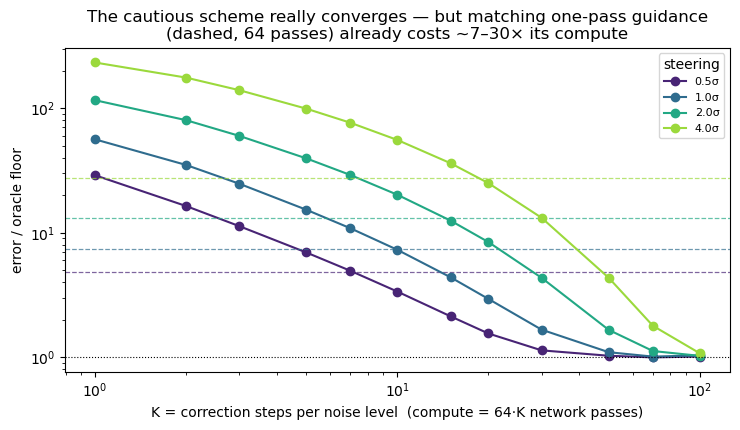

In [17]:
# A4: error vs compute for the Remy scheme, with one-pass DPS as the dashed bar
a4 = load("a4_remy.jsonl")
fl4 = a4[(a4.sampler == "oracle") & (a4.dim == 64)].groupby("shift").w2.median()
a1_ = load("a1_multiy.jsonl"); d64 = a1_[(a1_.dim == 64) & (a1_.N == 256)]
ofl = d64[d64.sampler == "oracle"].groupby(["shift", "y_seed"]).w2.median()
dpsr = (d64[d64.sampler == "dps"].set_index(["shift", "y_seed"]).w2 / ofl).groupby("shift").median()
rem = a4[(a4.sampler == "remy") & (a4.dim == 64) & (a4.eps == 0) & (a4.eps0 == 0.1)]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
cmap = plt.cm.viridis(np.linspace(.1, .85, 4))
for sh, col in zip([0.5, 1.0, 2.0, 4.0], cmap):
    g = rem[rem["shift"] == sh].groupby("K").w2.median() / fl4[sh]
    ax.plot(g.index, g.values, "o-", color=col, label=f"{sh}σ")
    ax.axhline(dpsr[sh], color=col, ls="--", lw=.9, alpha=.7)
ax.axhline(1, color="k", ls=":", lw=.8)
ax.set(xscale="log", yscale="log", xlabel="K = correction steps per noise level  (compute = 64·K network passes)",
       ylabel="error / oracle floor",
       title="The cautious scheme really converges — but matching one-pass guidance\n(dashed, 64 passes) already costs ~7–30× its compute")
ax.legend(title="steering", fontsize=8)
plt.tight_layout()


## II.5 Scorecard and where the program stands

Proposed verdicts for the frozen predictions (final scoring happens jointly, as
always — the table is a proposal; details in `HANDOFF_DAWN_2.md`):

| Prediction (frozen 2026-07-03, public before results) | Proposed |
|---|---|
| P-b: the pilot's structure is generic across observations, spread ≲10% | **HIT** — 24/24 skies, spreads 1–8% |
| P-c: the compensation trap fools all sample-based diagnostics | **MISS on the trap clause** — all three catch it; only the temperature scalar is fooled (exactly, at ε*=−0.28). Detection clause HIT. |
| P-d: amortized nets pass summaries but fail geometry ≥3× floor | **MISS** — they land at ~2.6× floor; steering, not amortization, is the weak link |
| P-e: the cautious mass-mapping scheme converges with K, misspec sign-flipped | **HIT** — monotone to floor; sign-flip confirmed; "warm at small K" true for the spread, with a simultaneous small-scale overshoot the scalar can't see |

**What the night adds up to.** The arena has graduated from *demonstrating* that
steering shortcuts are biased (Part I) to doing three jobs no other setup currently
does: it **priced** the field's flagship sampler in compute-for-accuracy; it
**cleared** the amortized class at this difficulty (and located its failure onset);
and it **audited the auditors** — finding, explaining, and repairing two real
preprocessing bugs in the community's own validation tools, bugs that are invisible
without an exact reference. Two upstream bug reports, one figure the mass-mapping
community can argue with, and a sharper headline for the note: *distribution-level
diagnostics are healthier than we predicted; scalar summaries and unaudited
preprocessing are the failure surface.*

---

# Part III — The certificate kill test (2026-07-04, daytime)

**The honest pivot.** Reading Part II's results cold, we judged them solid but thin:
diligence inside a toy, not news for the field. A structured brainstorm asked what
*would* matter, and converged on the real pain point: **on real data, nobody can tell
whether their steered sampler is lying** — there is no runtime correctness signal for
guided diffusion, anywhere. The idea: every guided sampler knows exactly what
modification it applied to its own dynamics, so one can accumulate, along the sampler's
own trajectories, the exact price of those modifications relative to the target it
*claims* to sample — and get a per-run, per-observation error meter, with no ground
truth needed. The arena's new job (and, retroactively, its best justification): it is
the **calibration facility** where such an instrument can be tested against exact truth
before anyone points it at the sky.

Before building anything ambitious we ran the pre-registered *kill test*: does the
meter's signal survive high dimension, or do the importance weights it is built on
degenerate into noise? Three predictions were stamped and frozen; gates were green
before the grid; ~630 runs later, verdicts:

1. **The meter survives — HIT, stronger than predicted.** Its reading rises
   monotonically with true damage at every dimension up to 128², and it ranks the
   good sampler below the biased one in every single configuration. This despite its
   raw weights being maximally degenerate (effective sample size ≈ 1 of 65,536).
2. **Repair is dead — a predicted-against MISS we're glad to have on the books.**
   We bet reweighting could *fix* a biased sampler's output at small dimension. It
   can't, anywhere: the exact math shows a guided sampler's *path* deviates ~100×
   more than its endpoint, so the weights are hopeless even when the answer is close.
   The product is certify-and-**rank**, not certify-and-repair.
3. **The meter tracks truth — HIT** (rank correlation 0.95 with the exact error over
   the whole grid), degrading gracefully within a fixed dimension at scale.

Two bonuses beyond the frozen questions. First, the bound has a beautiful anatomy:
for a *good* sampler the certificate is **tight** — it prices the actual error to
within 1–5% at every dimension — while for a bad one it is loose but loud. You can
certify quality precisely; you can only *flag* garbage (which is what you need).
Second, computing the certificate **mode by mode** instead of jointly turns it from
a degenerate instrument into a nearly exact one (per-mode effective sample sizes of
110–253 out of 256, and the summed reading reproduces the exact answer to four
significant figures for the good sampler). In the real world "mode by mode" becomes
"wavelet band by wavelet band" — a direct bridge to the sparsity lineage this whole
program grew out of.

Scope, measured rather than asserted: with a deliberately contaminated model the
certificate prices only the steering step — it is blind to model error in both
directions (the misspecification column shows it under- and over-reading exactly as
theory says). Certifying the model itself is the other two audits' job; this
instrument makes the division of labor explicit.


per-mode ESS (median over modes), 64²/1σ: good sampler 252/256, DPS 205/256, joint ESS for both: 1.0


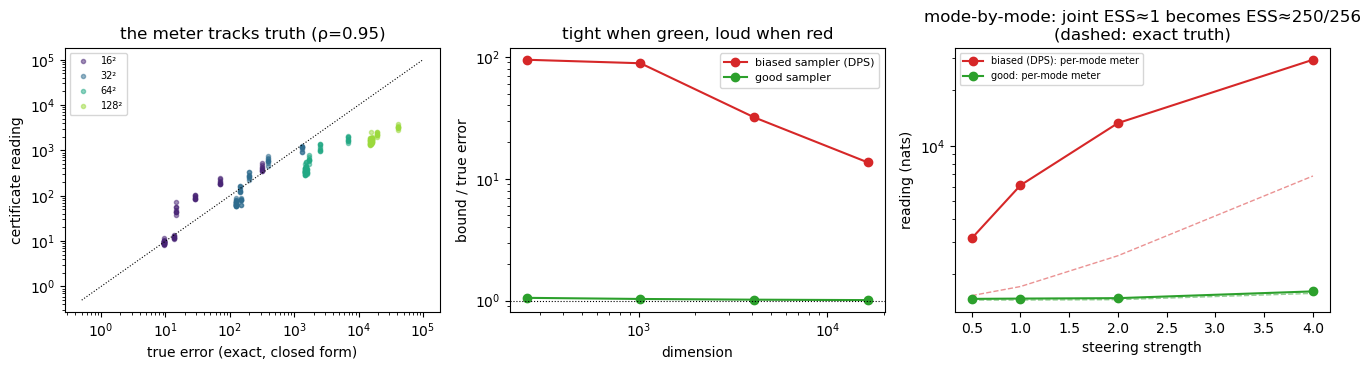

In [18]:
# Part III: the kill test in one row of panels, from the run's JSONL
ct = load("cert_killtest.jsonl").drop_duplicates(
    ["dim", "y_seed", "shift", "mode", "N", "seed", "eps"], keep="last")
core = ct[(ct.eps == 0) & (ct.y_seed == 999)]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
dims = sorted(core.dim.unique())
cmap = dict(zip(dims, plt.cm.viridis(np.linspace(.1, .85, len(dims)))))
ax = axes[0]
for d_ in dims:
    sub = core[(core.dim == d_) & (core["mode"] != "unguided") & (core.N == 256)]
    ax.loglog(sub.kl_end_exact, sub.kl_path_hat, "o", ms=3, alpha=.5,
              color=cmap[d_], label=f"{d_}²")
lims = [5e-1, 1e5]; ax.loglog(lims, lims, "k:", lw=.8)
ax.set(xlabel="true error (exact, closed form)", ylabel="certificate reading",
       title="the meter tracks truth (ρ=0.95)"); ax.legend(fontsize=7)
ax = axes[1]
for mode, col, lbl in (("dps", "#d62728", "biased sampler (DPS)"),
                       ("exact_guidance", "#2ca02c", "good sampler")):
    pts = (core[(core["mode"] == mode) & (core.N == 256) & (core["shift"] == 1.0)]
           .groupby("d").first())
    ax.loglog(pts.index, pts.kl_path_exact / pts.kl_end_exact, "o-", color=col,
              label=lbl)
ax.axhline(1, color="k", ls=":", lw=.8)
ax.set(xlabel="dimension", ylabel="bound / true error",
       title="tight when green, loud when red"); ax.legend(fontsize=8)
ax = axes[2]
mw = core[(core.dim == 64) & (core.N == 256) & core.kl_modes_sum.notna()]
for mode, col, lbl in (("dps", "#d62728", "biased (DPS)"),
                       ("exact_guidance", "#2ca02c", "good")):
    g = mw[mw["mode"] == mode].groupby("shift")
    ax.semilogy(g.kl_modes_sum.median().index, g.kl_modes_sum.median().values,
                "o-", color=col, label=f"{lbl}: per-mode meter")
    ax.semilogy(g.kl_end_exact.median().index, g.kl_end_exact.median().values,
                "--", color=col, alpha=.5, lw=1)
ax.set(xlabel="steering strength", ylabel="reading (nats)",
       title="mode-by-mode: joint ESS≈1 becomes ESS≈250/256\n(dashed: exact truth)")
ax.legend(fontsize=7)
plt.tight_layout()
print("per-mode ESS (median over modes), 64²/1σ:",
      f"good sampler {mw[mw['mode']=='exact_guidance'].ess_modes_med.median():.0f}/256,",
      f"DPS {mw[mw['mode']=='dps'].ess_modes_med.median():.0f}/256,",
      "joint ESS for both: 1.0")


**Stage 2, same day: the trained-network test — three predictions, three misses,
and the honest reshape.** We immediately ran the next disposable version: the same
certificate, block-by-block, on *trained* score networks (the pilot night's checkpoints).
Pre-registered expectations: per-mode health would survive (60%), the exact-law agreement
would transfer (70%), and the network would change the meter's value but not its meaning
(60%). **All three missed**, and the pre-registered reshape criterion fired: on a real
network the per-mode effective sample size collapses to ~3 of 256, and the reading is
dominated by the *network's* score error — guidance pulled through a learned network's
gradients is violent (the sampler's safety clip fires on up to 70% of steps), and the
certificate faithfully reports that violence, drowning the steering signal it was
designed to isolate.

The diagnosis is mechanistic, and it points somewhere useful. Everything that failed
lives on the *exponentiated* side of the instrument (the importance weights and their
normalizing constant). The *mean* side — the average log-weight — remained exact to
within one standard error on every configuration, including the trained networks: it is
unbiased no matter how degenerate the weights get. That statistic can't give an absolute
error without an unknowable constant — but **differences between steering schemes on the
same network cancel that constant exactly**. Which is precisely the question a
practitioner actually asks: *"on my model, which guidance scheme is less wrong?"* A
relative, runtime, any-dimension sampler ranking — that instrument survived everything
this arena threw at it.

**Where this leaves the program.** Absolute runtime certificates: bench-side methodology
(tight for good samplers, loud for bad ones, exactly priced — Part III above). Deployable
instrument: the relative certificate + the per-step violence profile, next to be
validated for operating characteristics on the bench — from data already on disk, before
any new framing hardens. Then the missed-mode table on exactly-solvable multimodal
targets, then the wrapper. Two days of this arena have now killed two beautiful ideas
cheaply (importance repair; naive per-mode certificates on real nets) and each time
handed back something sharper — which is the whole argument for keeping an exact oracle
in the loop.

---

## Appendix: glossary / symbol table

| Term / symbol | Meaning |
|---|---|
| score $\nabla_x \log p_t$ | "uphill in probability" vector field of the noised distribution at level $t$; the only thing a diffusion model actually learns |
| $\hat{x}_0 = \mathbb{E}[x_0\|x_t]$ | Tweedie denoiser: best guess of the clean field from the noisy one |
| tilt / tilted target $\sigma \propto p\,e^{r/\beta}$ | prior reweighted by a reward; with our quadratic $r$ it IS the Wiener posterior |
| $\beta$, "tilt strength" | steering strength; we quote it as how many prior $\sigma$'s the posterior mean moves (0.5–4) |
| $(\mu^*_k, \Sigma^*_k)$ | exact per-Fourier-mode posterior mean/variance — the ground truth everything is scored against |
| DPS / plug-in guidance | steer with the likelihood gradient at the point estimate $\hat x_0$; ignores denoiser uncertainty (Jensen gap) |
| SAP / reward-resampling | resample the particle population on $e^{r(\hat x_0)/\beta}$ at every step; selection compounds with depth |
| twist $\psi_t = \mathbb{E}[e^{r/\beta}\|x_t]$ | the optimal lookahead reweighting function for SMC; closed-form here, approximated in the wild |
| proper twisted SMC | SMC with the right weights AND twist-aware proposals — the correct algorithm; our on-floor sampler |
| terminal IS / best-of-$N$ | sample the prior, reweight at the end; dies of weight degeneracy in high $d$ |
| oracle floor | error of $N$ PERFECT samples; the ruler. Kill rule: methods must exceed $3\times$ it to matter |
| $W_2$, KL | distance of sampler output to truth (Gaussian closed forms per mode, summed) |
| $\gamma^*$ | effective temperature: which tempered posterior the sampler actually produced (1 = correct, >1 cold, <1 warm) |
| ESS | effective sample size $1/\sum \bar w_i^2$: how many particles actually contribute |
| $\hat{Z}$, $\log Z$ | estimated vs analytic evidence (normalizing constant); the honesty meter for SMC — seed of the "certificate" idea |
| $\varepsilon$ (misspec knob) | spectral-slope contamination of the score the sampler believes — the baryonic-feedback analog |
| $T$ (depth) | number of reverse-diffusion steps; SAP's over-tilt grows with it (the depth law) |
| PRM | process reward model: step-wise scorer used to steer LLM test-time search |
| AUROC | probability a confidence signal ranks a random correct answer above a random wrong one |
| none_frac | fraction of an LLM answer-population whose answers failed to parse — the truncation-artifact validity gate |
| pre-registration | predictions + kill criteria frozen and committed BEFORE the experiment runs; scored jointly after |
| PQMass | two-sample test: "are these two piles of samples from the same distribution?" (counts in random regions) |
| TARP | coverage test over many (observation, truth) pairs: claimed confidence vs achieved frequency |
| MIRA | region-counting score for conditional samplers with a known correct-model target value (2/3) |
| amortized inference | train the network to take the observation as input, so sampling IS posterior sampling — no steering step |
| $K$ (Remy scheme) | Langevin correction steps per noise level; the compute knob (network passes = $T\cdot K$) |
| $\varepsilon^*$ | the contamination at which DPS's bias exactly cancels in temperature (γ*=1) while geometry stays ~6× floor |
| steering certificate | per-run residual path-weights of a guided sampler vs its intended target: runtime error meter, no ground truth needed |
| path KL vs endpoint KL | error of the whole trajectory distribution vs error of the final samples; the certificate bounds the latter by the former (tight for good samplers, ~100× loose for bad ones) |
| k̂ (Pareto tail index) | "are these importance weights lying" diagnostic (PSIS); >1 means unusable for reweighting |
| per-mode (Rao-Blackwell) certificate | the certificate computed coordinate-wise: exact here, near-exact readings where the joint version degenerates; "wavelet-band-wise" in the wild |

*Repo: **[github.com/AndreasTersenov/tilt-audit](https://github.com/AndreasTersenov/tilt-audit)**
(public since 2026-07-03, before the arms-night results existed). Every claim above
traces to a JSONL in `results/`, a NIGHT_LOG entry, and a git commit made as it
happened.*
